# 0. Import thư viện

In [1]:
import os
import requests
import re
from html import unescape
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown


/Users/tnhatnguyendev2805/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 14

COLOR_MAIN = "#2563eb"
COLOR_ACCENT = "#f97316"
COLOR_GREEN = "#16a34a"
COLOR_RED = "#dc2626"
COLOR_PURPLE = "#7c3aed"
COLOR_GRAY = "#64748b"
PALETTE_CONTRAST = [COLOR_MAIN, COLOR_ACCENT, COLOR_GREEN, COLOR_PURPLE, COLOR_RED, "#0891b2", "#ca8a04", "#be123c"]


def title(text):
    display(Markdown(f"### {text}"))


def show_df(df, n=10):
    display(df.head(n))


def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    abs_error = np.abs(y_true - y_pred)
    sq_error = (y_true - y_pred) ** 2
    ss_res = np.sum(sq_error)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return {
        "MAE": abs_error.mean(),
        "RMSE": np.sqrt(sq_error.mean()),
        "WAPE": abs_error.sum() / (np.abs(y_true).sum() + 1e-12),
        "R2": 1 - ss_res / (ss_tot + 1e-12),
        "Bias": (y_pred - y_true).mean(),
    }


def display_metrics_table(rows, sort_by="MAE"):
    out = pd.DataFrame(rows)
    if sort_by in out.columns:
        out = out.sort_values(sort_by)
    display(out.round({"MAE": 3, "RMSE": 3, "WAPE": 4, "R2": 4, "Bias": 3}))
    return out

In [3]:
from matplotlib.ticker import FuncFormatter

target_col = "daily_revenue"

sns.set_theme(style="whitegrid", context="notebook")

BLUE = "#2563EB"
ORANGE = "#F97316"
GREEN = "#16A34A"
RED = "#DC2626"
PURPLE = "#7C3AED"
PINK = "#DB2777"
GRAY = "#64748B"
DARK = "#0F172A"

def format_number(x, pos=None):
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif abs(x) >= 1_000:
        return f"{x/1_000:.0f}K"
    return f"{x:.0f}"

num_formatter = FuncFormatter(format_number)

def add_bar_labels(ax, fmt="{:,.0f}", rotation=0, fontsize=10):
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[fmt.format(v.get_height()) for v in container],
            padding=3,
            fontsize=fontsize,
            rotation=rotation
        )

# 1. Load dữ liệu

In [4]:
def get_drive_file_id(drive_link):
    match = re.search(r"/d/([a-zA-Z0-9_-]+)|id=([a-zA-Z0-9_-]+)", drive_link)
    
    if not match:
        raise ValueError("Google Drive link is not valid.")
    
    return match.group(1) or match.group(2)


def read_csv_from_google_drive(drive_link, **read_csv_kwargs):
    file_id = get_drive_file_id(drive_link)

    session = requests.Session()
    base_url = "https://drive.google.com/uc"
    params = {
        "export": "download",
        "id": file_id
    }

    response = session.get(base_url, params=params, stream=True)
    response.raise_for_status()
    
    if "text/html" in response.headers.get("Content-Type", ""):
        html = response.text

        form_action = re.search(r'<form[^>]+action="([^"]+)"', html)
        if not form_action:
            raise RuntimeError(
                "Cannot get download link. Please check Google Drive sharing permission."
            )

        download_url = unescape(form_action.group(1))

        hidden_inputs = re.findall(
            r'<input[^>]+type="hidden"[^>]+name="([^"]+)"[^>]+value="([^"]*)"',
            html
        )

        download_params = dict(hidden_inputs)

        response = session.get(download_url, params=download_params, stream=True)
        response.raise_for_status()

        if "text/html" in response.headers.get("Content-Type", ""):
            raise RuntimeError(
                "Google Drive still returned HTML instead of CSV. "
                "Please check file permission or try again later."
            )

    response.raw.decode_content = True

    return pd.read_csv(response.raw, **read_csv_kwargs)

In [5]:
drive_link = "https://drive.google.com/file/d/1n-SU8OR7kBDl3iVMcQPLl7kCmUGiCHRk/view?usp=drive_link"

df_raw = read_csv_from_google_drive(drive_link)
df = df_raw.copy()
df["date"] = pd.to_datetime(df["date"])

for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]:
    df[col] = df[col].fillna("No Event").astype(str)

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "->", df["date"].max().date())
print("Stores:", df["store_id"].nunique(), sorted(df["store_id"].unique()))
print("States:", df["state_id"].nunique(), sorted(df["state_id"].unique()))
print("Categories:", df["cat_id"].nunique(), sorted(df["cat_id"].unique()))
print("Departments:", df["dept_id"].nunique(), sorted(df["dept_id"].unique()))

show_df(df, 5)

Shape: (135870, 56)
Date range: 2011-01-29 -> 2016-05-22
Stores: 10 ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
States: 3 ['CA', 'TX', 'WI']
Categories: 3 ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Departments: 7 ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']


,date,d,wm_yr_wk,store_id,state_id,cat_id,dept_id,daily_revenue,daily_units,item_count,active_item_count,weighted_avg_sell_price,has_sales,weekday,wday,month,year,quarter,week_of_year,day_of_month,day_of_year,day_of_week,day_of_week_num,is_weekend,year_month,event_name_1,event_type_1,event_name_2,event_type_2,event_count,snap_CA,snap_TX,snap_WI,snap_active,weather_location_id,location_name,weather_spatial_level,weather_code,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2,latitude_requested,longitude_requested,latitude_open_meteo,longitude_open_meteo,elevation_m,timezone,utc_offset_seconds,weather_source
0,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_1,681.1800,297,216,70,2.2935,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,No Event,No Event,No Event,No Event,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
1,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_2,"2,236.0100",674,398,154,3.3175,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,No Event,No Event,No Event,No Event,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
2,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_3,"4,323.4600",2268,823,285,1.9063,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,No Event,No Event,No Event,No Event,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
3,2011-01-29,d_1,11101,CA_1,CA,HOBBIES,HOBBIES_1,"1,276.8600",528,416,101,2.4183,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,No Event,No Event,No Event,No Event,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
4,2011-01-29,d_1,11101,CA_1,CA,HOBBIES,HOBBIES_2,93.0500,28,149,17,3.3232,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,No Event,No Event,No Event,No Event,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive


# 2. Schema, Key Và Leakage

In [6]:
key_cols = ["date", "store_id", "dept_id"]
target_col = "daily_revenue"

leakage_cols = ["daily_units", "active_item_count", "weighted_avg_sell_price", "has_sales"]
metadata_cols = ["store_id", "state_id", "cat_id", "dept_id", "item_count"]
calendar_cols = [
    "d", "wm_yr_wk", "weekday", "wday", "month", "year", "quarter", "week_of_year",
    "day_of_month", "day_of_year", "day_of_week", "day_of_week_num", "is_weekend", "year_month",
]
event_snap_cols = [
    "event_name_1", "event_type_1", "event_name_2", "event_type_2", "event_count",
    "snap_CA", "snap_TX", "snap_WI", "snap_active",
]
weather_cols = [
    "weather_location_id", "location_name", "weather_spatial_level", "weather_code",
    "temperature_max_c", "temperature_min_c", "temperature_mean_c", "apparent_temperature_mean_c",
    "precipitation_mm", "rain_mm", "snowfall_cm", "wind_speed_max_kmh", "wind_gusts_max_kmh",
    "shortwave_radiation_mj_m2", "latitude_requested", "longitude_requested", "latitude_open_meteo",
    "longitude_open_meteo", "elevation_m", "timezone", "utc_offset_seconds", "weather_source",
]

schema_summary = pd.DataFrame({
    "group": ["key", "target", "leakage_same_day", "metadata", "calendar", "event_snap", "weather"],
    "n_cols": [len(key_cols), 1, len(leakage_cols), len(metadata_cols), len(calendar_cols), len(event_snap_cols), len(weather_cols)],
    "columns": [key_cols, [target_col], leakage_cols, metadata_cols, calendar_cols, event_snap_cols, weather_cols],
})
display(schema_summary)

print("Duplicate key rows:", df.duplicated(key_cols).sum())
print("Rows per date, unique counts:")
display(df.groupby("date").size().value_counts().sort_index().rename_axis("rows_per_date").to_frame("n_dates"))


,group,n_cols,columns
0,key,3,"[date, store_id, dept_id]"
1,target,1,[daily_revenue]
2,leakage_same_day,4,"[daily_units, active_item_count, weighted_avg_..."
3,metadata,5,"[store_id, state_id, cat_id, dept_id, item_count]"
4,calendar,14,"[d, wm_yr_wk, weekday, wday, month, year, quar..."
5,event_snap,9,"[event_name_1, event_type_1, event_name_2, eve..."
6,weather,22,"[weather_location_id, location_name, weather_s..."


Duplicate key rows: 0
Rows per date, unique counts:


,n_dates
rows_per_date,
70,1941


# 3. Data Quality Check

In [7]:
quality_summary = pd.DataFrame({
    "metric": [
        "rows", "columns", "duplicate_keys", "missing_values_after_event_fill", "negative_revenue", "zero_revenue_rows",
        "min_revenue", "median_revenue", "mean_revenue", "p95_revenue", "p99_revenue", "max_revenue",
    ],
    "value": [
        df.shape[0], df.shape[1], df.duplicated(key_cols).sum(), df.isna().sum().sum(),
        (df[target_col] < 0).sum(), (df[target_col] == 0).sum(),
        df[target_col].min(), df[target_col].median(), df[target_col].mean(),
        df[target_col].quantile(0.95), df[target_col].quantile(0.99), df[target_col].max(),
    ]
})
display(quality_summary)

missing_by_col = df.isna().sum().loc[lambda s: s > 0].sort_values(ascending=False)
print("Columns with missing values after event fill:", len(missing_by_col))
if len(missing_by_col) > 0:
    display(missing_by_col.to_frame("missing_count"))

core_numeric = ["daily_revenue", "daily_units", "item_count", "active_item_count", "weighted_avg_sell_price", "has_sales"]
display(df[core_numeric].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)


,metric,value
0,rows,"135,870.0000"
1,columns,56.0000
2,duplicate_keys,0.0000
3,missing_values_after_event_fill,363.0000
4,negative_revenue,0.0000
5,zero_revenue_rows,363.0000
6,min_revenue,0.0000
7,median_revenue,985.7900
8,mean_revenue,"1,410.0062"
9,p95_revenue,"4,258.8290"


Columns with missing values after event fill: 1


,missing_count
weighted_avg_sell_price,363


,count,mean,std,min,1%,5%,50%,95%,99%,max
daily_revenue,"135,870.0000","1,410.0062","1,384.2343",0.0000,15.3800,42.6345,985.7900,"4,258.8290","6,484.8792","11,198.9500"
daily_units,"135,870.0000",492.5824,603.8029,0.0000,6.0000,18.0000,288.0000,"1,841.5500","2,878.3100","5,118.0000"
item_count,"135,870.0000",435.5714,206.2730,149.0000,149.0000,149.0000,416.0000,823.0000,823.0000,823.0000
active_item_count,"135,870.0000",139.3926,107.7646,0.0000,5.0000,12.0000,111.0000,370.0000,471.0000,621.0000
weighted_avg_sell_price,"135,507.0000",3.2682,1.0581,0.2000,1.4988,1.9266,3.1447,5.1735,5.7246,10.9650
has_sales,"135,870.0000",0.9973,0.0516,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


# 4. Distribution Target

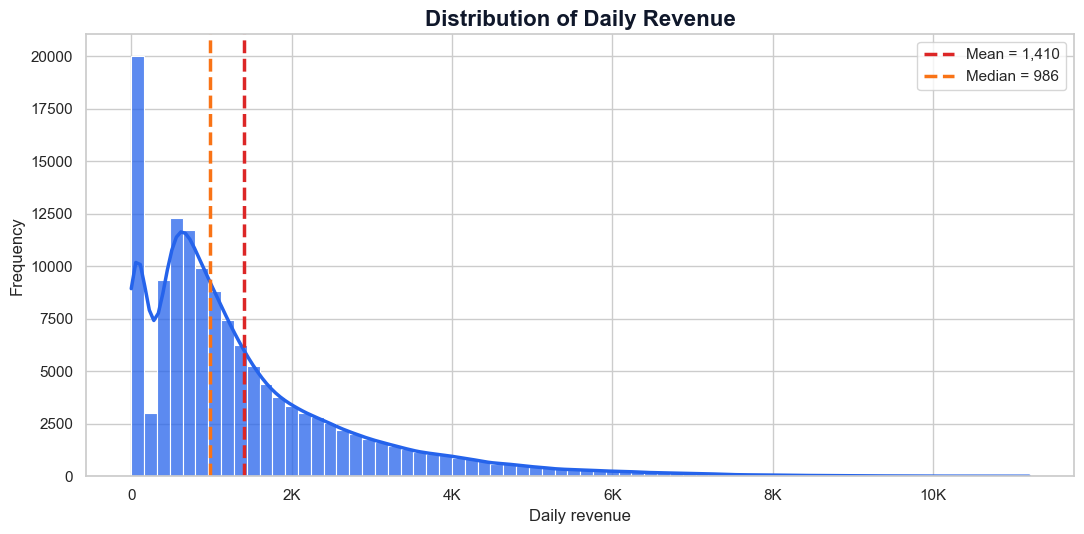

In [8]:
mean_value = df[target_col].mean()
median_value = df[target_col].median()

plt.figure(figsize=(11, 5.5))

ax = sns.histplot(
    data=df,
    x=target_col,
    bins=70,
    kde=True,
    color=BLUE,
    edgecolor="white",
    alpha=0.75,
    line_kws={"linewidth": 2.5}
)

ax.axvline(
    mean_value,
    color=RED,
    linestyle="--",
    linewidth=2.5,
    label=f"Mean = {mean_value:,.0f}"
)

ax.axvline(
    median_value,
    color=ORANGE,
    linestyle="--",
    linewidth=2.5,
    label=f"Median = {median_value:,.0f}"
)

ax.set_title("Distribution of Daily Revenue", fontsize=16, fontweight="bold", color=DARK)
ax.set_xlabel("Daily revenue")
ax.set_ylabel("Frequency")
ax.xaxis.set_major_formatter(num_formatter)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

In [9]:
q1 = df["daily_revenue"].quantile(0.25)
q3 = df["daily_revenue"].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

outlier_mask = df["daily_revenue"] > upper_bound

outlier_summary = pd.DataFrame({
    "metric": [
        "Q1",
        "Q3",
        "IQR",
        "IQR upper bound",
        "High outlier count",
        "High outlier pct"
    ],
    "value": [
        q1,
        q3,
        iqr,
        upper_bound,
        outlier_mask.sum(),
        outlier_mask.mean() * 100
    ]
})

display(outlier_summary)

,metric,value
0,Q1,500.7100
1,Q3,"1,900.5075"
2,IQR,"1,399.7975"
3,IQR upper bound,"4,000.2037"
4,High outlier count,"8,194.0000"
5,High outlier pct,6.0308


In [10]:
df["store_dept"] = df["store_id"].astype(str) + "_" + df["dept_id"].astype(str)

outlier_store_dept_summary = (
    df[outlier_mask]
    .groupby("store_dept")
    .agg(
        outlier_rows=("daily_revenue", "size"),
        outlier_revenue=("daily_revenue", "sum"),
        mean_outlier_revenue=("daily_revenue", "mean")
    )
    .sort_values("outlier_revenue", ascending=False)
    .head(15)
    .reset_index()
)

display(outlier_store_dept_summary)

,store_dept,outlier_rows,outlier_revenue,mean_outlier_revenue
0,CA_3_FOODS_3,1844,"12,115,270.0333","6,570.1031"
1,CA_1_FOODS_3,1395,"7,495,350.1818","5,373.0109"
2,TX_2_FOODS_3,1053,"5,154,020.9659","4,894.6068"
3,CA_3_HOUSEHOLD_1,957,"4,925,120.6575","5,146.4166"
4,WI_3_FOODS_3,691,"3,356,686.6522","4,857.7231"
5,WI_2_FOODS_3,672,"3,354,965.4913","4,992.5082"
6,TX_3_FOODS_3,445,"2,010,876.3213","4,518.8232"
7,WI_1_FOODS_3,283,"1,313,814.9431","4,642.4556"
8,TX_1_FOODS_3,261,"1,161,329.0033","4,449.5364"
9,CA_2_FOODS_3,199,"1,007,253.3918","5,061.5748"


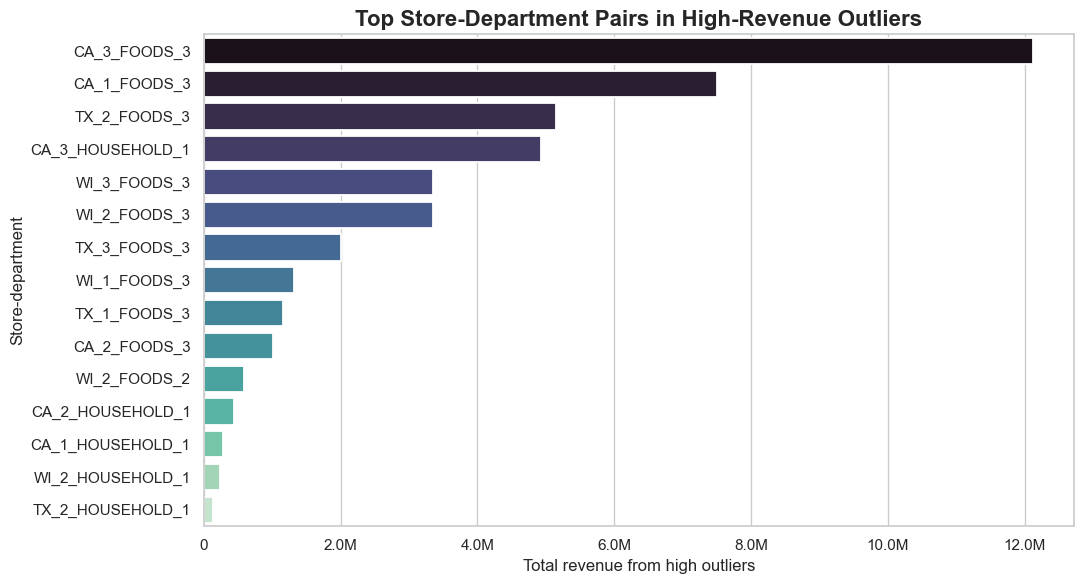

In [11]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=outlier_store_dept_summary,
    x="outlier_revenue",
    y="store_dept",
    palette=sns.color_palette("mako", len(outlier_store_dept_summary)),
    edgecolor="white",
    linewidth=1.3
)

ax.set_title(
    "Top Store-Department Pairs in High-Revenue Outliers",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Total revenue from high outliers")
ax.set_ylabel("Store-department")
ax.xaxis.set_major_formatter(num_formatter)

plt.tight_layout()
plt.show()

**Insight**

- Phân phối của daily_revenue bị lệch phải rõ rệt. Median khoảng 986, trong khi mean khoảng 1,410, cho thấy phần lớn quan sát có doanh thu ở mức thấp đến trung bình, nhưng tồn tại một nhóm quan sát doanh thu cao kéo giá trị trung bình lên. Vì vậy, khi đánh giá mô hình không nên chỉ dùng RMSE, mà nên ưu tiên thêm MAE và WAPE để phản ánh sai số dự báo theo góc nhìn business.
- Doanh thu cao không phải là lỗi dữ liệu ngẫu nhiên, mà là một pattern kinh doanh thật. Các giá trị high-revenue chủ yếu đến từ những tổ hợp store-department có quy mô lớn, đặc biệt là FOODS_3 ở một số store như CA_3, CA_1, TX_2.

# 5. Revenue By Category, Department Và Store

In [12]:
target_col = "daily_revenue"

def revenue_group_summary(data, group_col, target_col="daily_revenue"):
    summary = (
        data.groupby(group_col)
        .agg(
            rows=(target_col, "size"),
            total_revenue=(target_col, "sum"),
            mean_revenue=(target_col, "mean"),
            median_revenue=(target_col, "median"),
            std_revenue=(target_col, "std")
        )
        .reset_index()
        .sort_values("total_revenue", ascending=False)
    )
    
    summary["row_share_pct"] = summary["rows"] / len(data) * 100
    summary["revenue_share_pct"] = (
        summary["total_revenue"] / data[target_col].sum() * 100
    )
    
    return summary


cat_summary = revenue_group_summary(df, "cat_id", target_col)
dept_summary = revenue_group_summary(df, "dept_id", target_col)
store_summary = revenue_group_summary(df, "store_id", target_col)

display(cat_summary)
display(dept_summary)
display(store_summary)

,cat_id,rows,total_revenue,mean_revenue,median_revenue,std_revenue,row_share_pct,revenue_share_pct
0,FOODS,58230,"111,140,025.4793","1,908.6386","1,263.7400","1,653.7060",42.8571,58.0131
2,HOUSEHOLD,38820,"57,115,876.4174","1,471.3003","1,199.4800","1,067.6260",28.5714,29.8135
1,HOBBIES,38820,"23,321,644.2179",600.7636,197.1500,657.9557,28.5714,12.1735


,dept_id,rows,total_revenue,mean_revenue,median_revenue,std_revenue,row_share_pct,revenue_share_pct
2,FOODS_3,19410,"72,345,863.7778","3,727.2470","3,440.6800","1,553.0280",14.2857,37.7632
5,HOUSEHOLD_1,19410,"42,132,778.5504","2,170.6738","1,963.5200","1,067.0314",14.2857,21.9925
1,FOODS_2,19410,"25,592,365.6414","1,318.5145","1,226.6250",737.9398,14.2857,13.3588
3,HOBBIES_1,19410,"22,120,244.5109","1,139.6314","1,025.9850",532.6740,14.2857,11.5464
6,HOUSEHOLD_2,19410,"14,983,097.8670",771.9267,653.3250,403.5542,14.2857,7.8209
0,FOODS_1,19410,"13,201,796.0601",680.1544,631.0450,288.1641,14.2857,6.8911
4,HOBBIES_2,19410,"1,201,399.7070",61.8959,55.7650,36.1287,14.2857,0.6271


,store_id,rows,total_revenue,mean_revenue,median_revenue,std_revenue,row_share_pct,revenue_share_pct
2,CA_3,13587,"32,699,137.6831","2,406.6488","1,692.8200","2,145.6796",10.0000,17.0684
0,CA_1,13587,"22,954,283.7756","1,689.4299","1,231.9300","1,572.6592",10.0000,11.9817
5,TX_2,13587,"20,893,002.1948","1,537.7200","1,092.2900","1,369.5680",10.0000,10.9058
6,TX_3,13587,"18,190,298.6966","1,338.8017",938.1500,"1,167.6382",10.0000,9.4950
8,WI_2,13587,"18,131,985.0430","1,334.5098",765.8500,"1,367.4082",10.0000,9.4646
1,CA_2,13587,"17,848,209.3906","1,313.6240","1,089.1200","1,070.5773",10.0000,9.3164
9,WI_3,13587,"17,250,126.1765","1,269.6052",779.9600,"1,261.1953",10.0000,9.0043
4,TX_1,13587,"16,037,341.1457","1,180.3445",795.7500,"1,072.3072",10.0000,8.3712
7,WI_1,13587,"15,107,433.8073","1,111.9036",877.0700,992.7073,10.0000,7.8858
3,CA_4,13587,"12,465,728.2013",917.4747,711.1000,769.6703,10.0000,6.5069


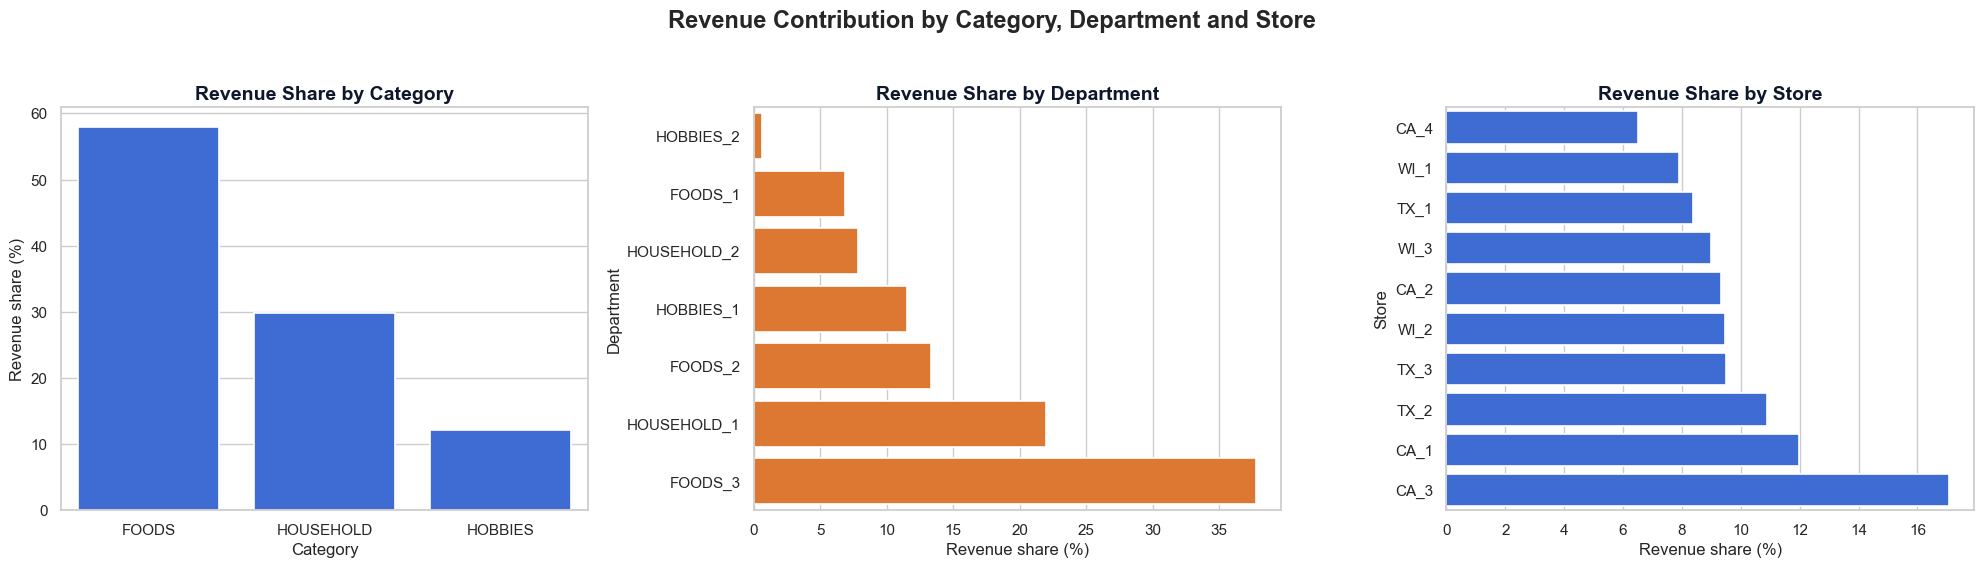

In [13]:
sns.set_theme(style="whitegrid", context="notebook")

BLUE = "#2563EB"
ORANGE = "#F97316"
DARK = "#0F172A"

def format_number(x, pos=None):
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif abs(x) >= 1_000:
        return f"{x/1_000:.0f}K"
    return f"{x:.0f}"

num_formatter = FuncFormatter(format_number)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# Category
sns.barplot(
    data=cat_summary,
    x="cat_id",
    y="revenue_share_pct",
    color=BLUE,
    edgecolor="white",
    linewidth=1.2,
    ax=axes[0]
)

axes[0].set_title("Revenue Share by Category", fontsize=14, fontweight="bold", color=DARK)
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Revenue share (%)")

# Department
dept_plot = dept_summary.sort_values("revenue_share_pct", ascending=True)

sns.barplot(
    data=dept_plot,
    x="revenue_share_pct",
    y="dept_id",
    color=ORANGE,
    edgecolor="white",
    linewidth=1.2,
    ax=axes[1]
)

axes[1].set_title("Revenue Share by Department", fontsize=14, fontweight="bold", color=DARK)
axes[1].set_xlabel("Revenue share (%)")
axes[1].set_ylabel("Department")

# Store
store_plot = store_summary.sort_values("revenue_share_pct", ascending=True)

sns.barplot(
    data=store_plot,
    x="revenue_share_pct",
    y="store_id",
    color=BLUE,
    edgecolor="white",
    linewidth=1.2,
    ax=axes[2]
)

axes[2].set_title("Revenue Share by Store", fontsize=14, fontweight="bold", color=DARK)
axes[2].set_xlabel("Revenue share (%)")
axes[2].set_ylabel("Store")

plt.suptitle(
    "Revenue Contribution by Category, Department and Store",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

In [14]:
def plot_mean_revenue_by_group(data, group_col, title):
    summary = revenue_group_summary(data, group_col, target_col)
    summary = summary.sort_values("mean_revenue", ascending=False)

    plt.figure(figsize=(11, 5.5))

    ax = sns.barplot(
        data=summary,
        x="mean_revenue",
        y=group_col,
        color=BLUE,
        edgecolor="white",
        linewidth=1.2
    )

    ax.set_title(title, fontsize=15, fontweight="bold", color=DARK)
    ax.set_xlabel("Mean daily revenue per row")
    ax.set_ylabel(group_col)

    plt.tight_layout()
    plt.show()

    display(summary[[group_col, "rows", "row_share_pct", "revenue_share_pct", "mean_revenue", "median_revenue"]])

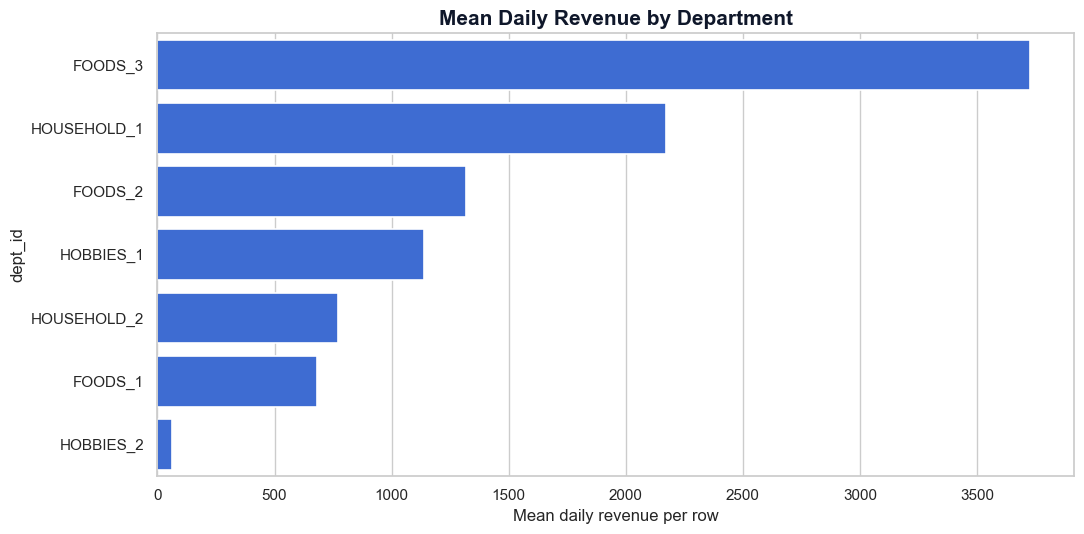

,dept_id,rows,row_share_pct,revenue_share_pct,mean_revenue,median_revenue
2,FOODS_3,19410,14.2857,37.7632,"3,727.2470","3,440.6800"
5,HOUSEHOLD_1,19410,14.2857,21.9925,"2,170.6738","1,963.5200"
1,FOODS_2,19410,14.2857,13.3588,"1,318.5145","1,226.6250"
3,HOBBIES_1,19410,14.2857,11.5464,"1,139.6314","1,025.9850"
6,HOUSEHOLD_2,19410,14.2857,7.8209,771.9267,653.3250
0,FOODS_1,19410,14.2857,6.8911,680.1544,631.0450
4,HOBBIES_2,19410,14.2857,0.6271,61.8959,55.7650


In [15]:
plot_mean_revenue_by_group(
    df,
    group_col="dept_id",
    title="Mean Daily Revenue by Department"
)

**Insight** 

- Kết quả phân tích cho thấy doanh thu không phân bố đều giữa các nhóm sản phẩm và cửa hàng. Ở cấp category, `FOODS` là nhóm đóng góp doanh thu lớn nhất, chiếm hơn một nửa tổng doanh thu. Điều này cho thấy `FOODS` là nhóm sản phẩm chủ lực trong dữ liệu.

- Ở cấp department, `FOODS_3` là nhóm nổi bật nhất cả về tỷ trọng doanh thu lẫn doanh thu trung bình trên mỗi quan sát. Điều này cho thấy `FOODS_3` không chỉ lớn do có nhiều dữ liệu, mà bản thân mỗi quan sát của nhóm này cũng tạo ra doanh thu cao hơn. Vì vậy, `FOODS_3` có thể được xem là revenue driver chính của dataset.

- Ở cấp store, `CA_3`, `CA_1` và `TX_2` là các cửa hàng có tỷ trọng doanh thu cao hơn các store còn lại. Tuy nhiên, mức chênh lệch giữa các store không mạnh bằng sự khác biệt giữa các department. Điều này cho thấy yếu tố nhóm sản phẩm, đặc biệt là `dept_id`, có ảnh hưởng mạnh hơn đến sự khác biệt doanh thu so với yếu tố store.

**Kết luận**

- Từ các insight trên, các biến `cat_id`, `dept_id` và `store_id` được giữ lại làm các feature cơ bản trong mô hình. Trong đó, `dept_id` được xem là biến phân nhóm quan trọng nhất vì phản ánh rõ sự khác biệt về quy mô doanh thu giữa các nhóm sản phẩm.

 - Các biến này không gây leakage vì đây là thông tin có sẵn trước thời điểm dự báo.


# 6. Time Trend, Seasonality Và Day-Of-Week


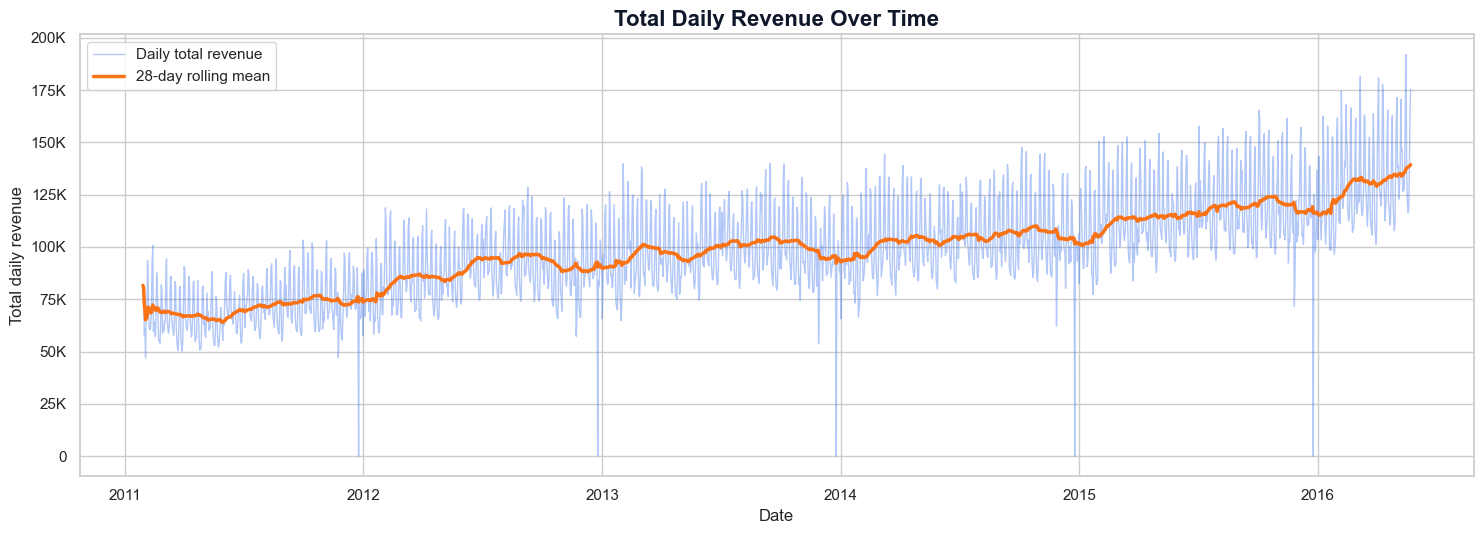

In [16]:
import pandas as pd              
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

df["date"] = pd.to_datetime(df["date"])

target_col = "daily_revenue"

sns.set_theme(style="whitegrid", context="notebook")

BLUE = "#2563EB"
ORANGE = "#F97316"
DARK = "#0F172A"

def format_number(x, pos=None):
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif abs(x) >= 1_000:
        return f"{x/1_000:.0f}K"
    return f"{x:.0f}"

num_formatter = FuncFormatter(format_number)

daily_total = (
    df.groupby("date", as_index=False)
    .agg(total_revenue=(target_col, "sum"))
)

# Rolling 28 ngày để thấy trend mượt hơn
daily_total["revenue_roll_28"] = (
    daily_total["total_revenue"]
    .rolling(window=28, min_periods=1)
    .mean()
)

plt.figure(figsize=(15, 5.5))

plt.plot(
    daily_total["date"],
    daily_total["total_revenue"],
    color=BLUE,
    alpha=0.35,
    linewidth=1,
    label="Daily total revenue"
)

plt.plot(
    daily_total["date"],
    daily_total["revenue_roll_28"],
    color=ORANGE,
    linewidth=2.5,
    label="28-day rolling mean"
)

plt.title(
    "Total Daily Revenue Over Time",
    fontsize=16,
    fontweight="bold",
    color=DARK
)

plt.xlabel("Date")
plt.ylabel("Total daily revenue")
plt.gca().yaxis.set_major_formatter(num_formatter)
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# Tìm các ngày tổng doanh thu thấp bất thường
daily_total = (
    df.groupby("date", as_index=False)
    .agg(total_revenue=("daily_revenue", "sum"))
)

low_threshold = daily_total["total_revenue"].quantile(0.01)

low_days = daily_total[
    daily_total["total_revenue"] <= low_threshold
].copy()

low_days["year"] = low_days["date"].dt.year
low_days["month"] = low_days["date"].dt.month
low_days["day"] = low_days["date"].dt.day
low_days["day_of_week"] = low_days["date"].dt.day_name()

display(low_days.sort_values("date").head(30))
display(low_days.groupby(["month", "day"]).size().reset_index(name="count").sort_values("count", ascending=False))

,date,total_revenue,year,month,day,day_of_week
4,2011-02-02,"46,959.9500",2011,2,2,Wednesday
26,2011-02-24,"53,986.3402",2011,2,24,Thursday
53,2011-03-23,"51,681.8202",2011,3,23,Wednesday
54,2011-03-24,"50,469.3600",2011,3,24,Thursday
59,2011-03-29,"52,571.0903",2011,3,29,Tuesday
60,2011-03-30,"50,143.6300",2011,3,30,Wednesday
87,2011-04-26,"50,791.3700",2011,4,26,Tuesday
88,2011-04-27,"50,877.0202",2011,4,27,Wednesday
89,2011-04-28,"51,953.2199",2011,4,28,Thursday
109,2011-05-18,"52,915.5202",2011,5,18,Wednesday


,month,day,count
15,12,25,5
0,2,2,1
1,2,24,1
2,3,23,1
3,3,24,1
4,3,29,1
5,3,30,1
6,4,26,1
7,4,27,1
8,4,28,1


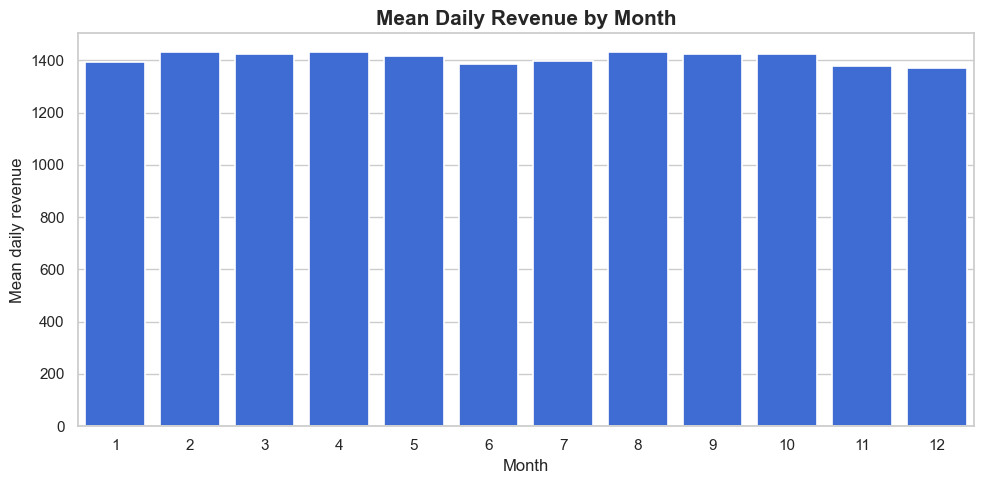

,month,mean_revenue,median_revenue,total_revenue
0,1,"1,395.1496",984.6450,"15,430,354.8746"
1,2,"1,431.4043","1,009.7950","17,033,711.6230"
2,3,"1,425.0377",993.2150,"18,553,991.4659"
3,4,"1,429.8650",985.0100,"18,016,298.6820"
4,5,"1,416.1829",983.0050,"17,546,506.2858"
5,6,"1,387.3884",985.2800,"14,567,578.6933"
6,7,"1,397.1953",979.4650,"15,159,569.1306"
7,8,"1,430.0691",986.2000,"15,516,249.4806"
8,9,"1,424.4622",991.3550,"14,956,853.5287"
9,10,"1,424.2631",981.7400,"15,453,255.1458"


In [18]:
month_summary = (
    df.groupby("month", as_index=False)
    .agg(
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median"),
        total_revenue=("daily_revenue", "sum")
    )
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=month_summary,
    x="month",
    y="mean_revenue",
    color="#2563EB",
    edgecolor="white",
    linewidth=1.2
)

ax.set_title("Mean Daily Revenue by Month", fontsize=15, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily revenue")

plt.tight_layout()
plt.show()

display(month_summary)

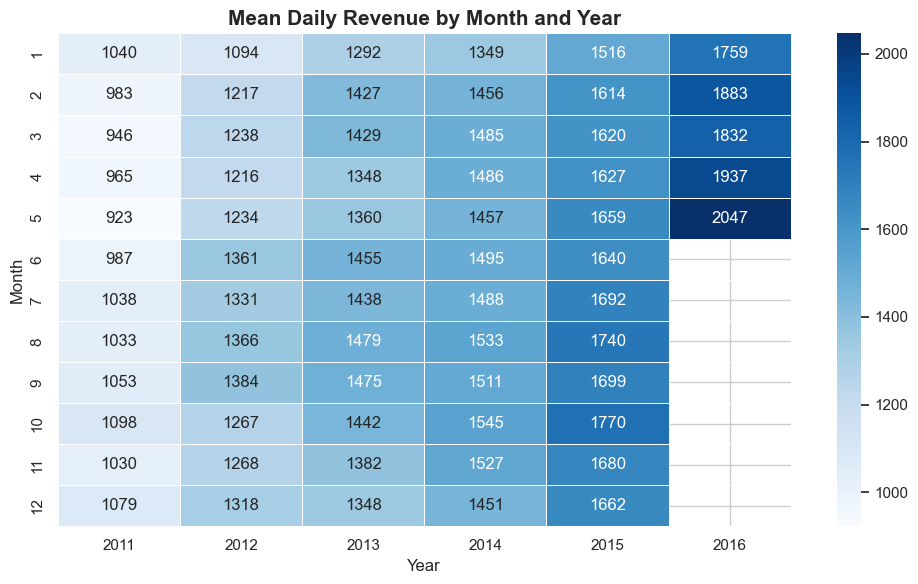

In [19]:
month_year_summary = (
    df.groupby(["year", "month"], as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"))
)

pivot_month_year = month_year_summary.pivot(
    index="month",
    columns="year",
    values="mean_revenue"
)

plt.figure(figsize=(10, 6))

ax = sns.heatmap(
    pivot_month_year,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5
)

ax.set_title(
    "Mean Daily Revenue by Month and Year",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Year")
ax.set_ylabel("Month")

plt.tight_layout()
plt.show()

# display(pivot_month_year)

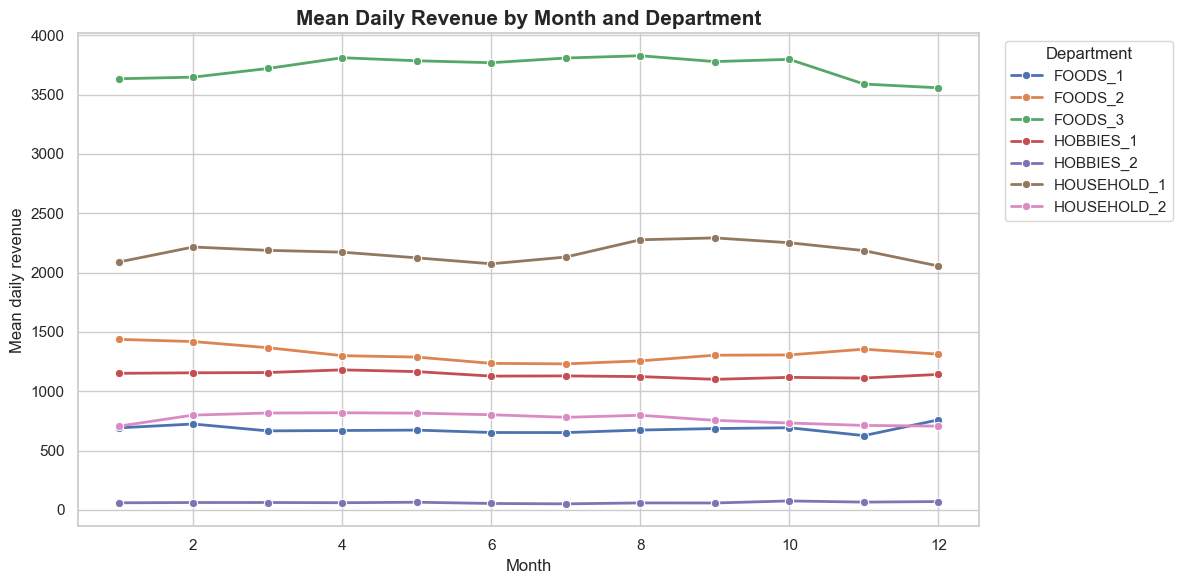

In [20]:
dept_month_summary = (
    df.groupby(["dept_id", "month"], as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"))
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=dept_month_summary,
    x="month",
    y="mean_revenue",
    hue="dept_id",
    marker="o",
    linewidth=2
)

ax.set_title(
    "Mean Daily Revenue by Month and Department",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily revenue")
ax.legend(title="Department", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [21]:
# Đảm bảo có biến thứ trong tuần
df["date"] = pd.to_datetime(df["date"])
df["day_of_week_num"] = df["date"].dt.dayofweek
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["day_of_week_num"].isin([5, 6]).astype(int)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

dow_summary = (
    df.groupby("day_of_week", as_index=False)
    .agg(
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median"),
        total_revenue=("daily_revenue", "sum"),
        rows=("daily_revenue", "size")
    )
)

dow_summary["day_of_week"] = pd.Categorical(
    dow_summary["day_of_week"],
    categories=weekday_order,
    ordered=True
)

dow_summary = dow_summary.sort_values("day_of_week")

weekend_summary = (
    df.groupby("is_weekend", as_index=False)
    .agg(
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median"),
        total_revenue=("daily_revenue", "sum"),
        rows=("daily_revenue", "size")
    )
)

weekend_summary["group"] = weekend_summary["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

display(dow_summary)
display(weekend_summary)

,day_of_week,mean_revenue,median_revenue,total_revenue,rows
1,Monday,"1,355.1652",942.1250,"26,276,652.5147",19390
5,Tuesday,"1,242.3780",888.9250,"24,089,709.3533",19390
6,Wednesday,"1,227.6076",888.0650,"23,803,312.2758",19390
4,Thursday,"1,233.0309",890.5600,"23,908,468.5033",19390
0,Friday,"1,395.2479","1,010.8800","27,053,857.7093",19390
2,Saturday,"1,703.1374","1,213.3600","33,143,054.1091",19460
3,Sunday,"1,711.3305","1,180.2400","33,302,491.6491",19460


,is_weekend,mean_revenue,median_revenue,total_revenue,rows,group
0,0,"1,290.6859",922.8850,"125,132,000.3563",96950,Weekday
1,1,"1,707.2340","1,196.5549","66,445,545.7582",38920,Weekend


In [22]:
dept_weekend_summary = (
    df.groupby(["dept_id", "is_weekend"], as_index=False)
    .agg(
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median"),
        rows=("daily_revenue", "size")
    )
)

dept_weekend_pivot = dept_weekend_summary.pivot(
    index="dept_id",
    columns="is_weekend",
    values="mean_revenue"
).reset_index()

dept_weekend_pivot.columns = ["dept_id", "weekday_mean", "weekend_mean"]

dept_weekend_pivot["weekend_uplift"] = (
    dept_weekend_pivot["weekend_mean"] - dept_weekend_pivot["weekday_mean"]
)

dept_weekend_pivot["weekend_uplift_pct"] = (
    dept_weekend_pivot["weekend_uplift"] / dept_weekend_pivot["weekday_mean"] * 100
)

dept_weekend_pivot = dept_weekend_pivot.sort_values(
    "weekend_uplift_pct",
    ascending=False
)

display(dept_weekend_pivot)

,dept_id,weekday_mean,weekend_mean,weekend_uplift,weekend_uplift_pct
5,HOUSEHOLD_1,"1,945.4875","2,731.6144",786.1269,40.4077
6,HOUSEHOLD_2,695.0291,963.4793,268.4503,38.6243
2,FOODS_3,"3,408.5132","4,521.2150","1,112.7018",32.6448
3,HOBBIES_1,"1,052.8123","1,355.8981",303.0858,28.7882
1,FOODS_2,"1,226.2279","1,548.4009",322.1730,26.2735
4,HOBBIES_2,58.7455,69.7437,10.9982,18.7218
0,FOODS_1,647.9859,760.2861,112.3002,17.3307


In [23]:
dept_year_weekend = (
    df.groupby(["year", "dept_id", "is_weekend"], as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"))
)

dept_year_weekend_pivot = dept_year_weekend.pivot_table(
    index=["year", "dept_id"],
    columns="is_weekend",
    values="mean_revenue"
).reset_index()

dept_year_weekend_pivot.columns = [
    "year", "dept_id", "weekday_mean", "weekend_mean"
]

dept_year_weekend_pivot["weekend_uplift_pct"] = (
    (dept_year_weekend_pivot["weekend_mean"] - dept_year_weekend_pivot["weekday_mean"])
    / dept_year_weekend_pivot["weekday_mean"] * 100
)

display(
    dept_year_weekend_pivot
    .sort_values(["dept_id", "year"])
)

,year,dept_id,weekday_mean,weekend_mean,weekend_uplift_pct
0,2011,FOODS_1,435.0566,530.0808,21.8418
7,2012,FOODS_1,608.7592,741.6398,21.8281
14,2013,FOODS_1,658.6550,767.3381,16.5008
21,2014,FOODS_1,675.6955,777.2360,15.0275
28,2015,FOODS_1,767.0476,872.6144,13.7627
35,2016,FOODS_1,848.4739,"1,000.9876",17.9751
1,2011,FOODS_2,932.6315,"1,145.6780",22.8436
8,2012,FOODS_2,"1,054.5985","1,325.4382",25.6818
15,2013,FOODS_2,"1,148.3218","1,449.1749",26.1994
22,2014,FOODS_2,"1,215.8118","1,552.8366",27.7201


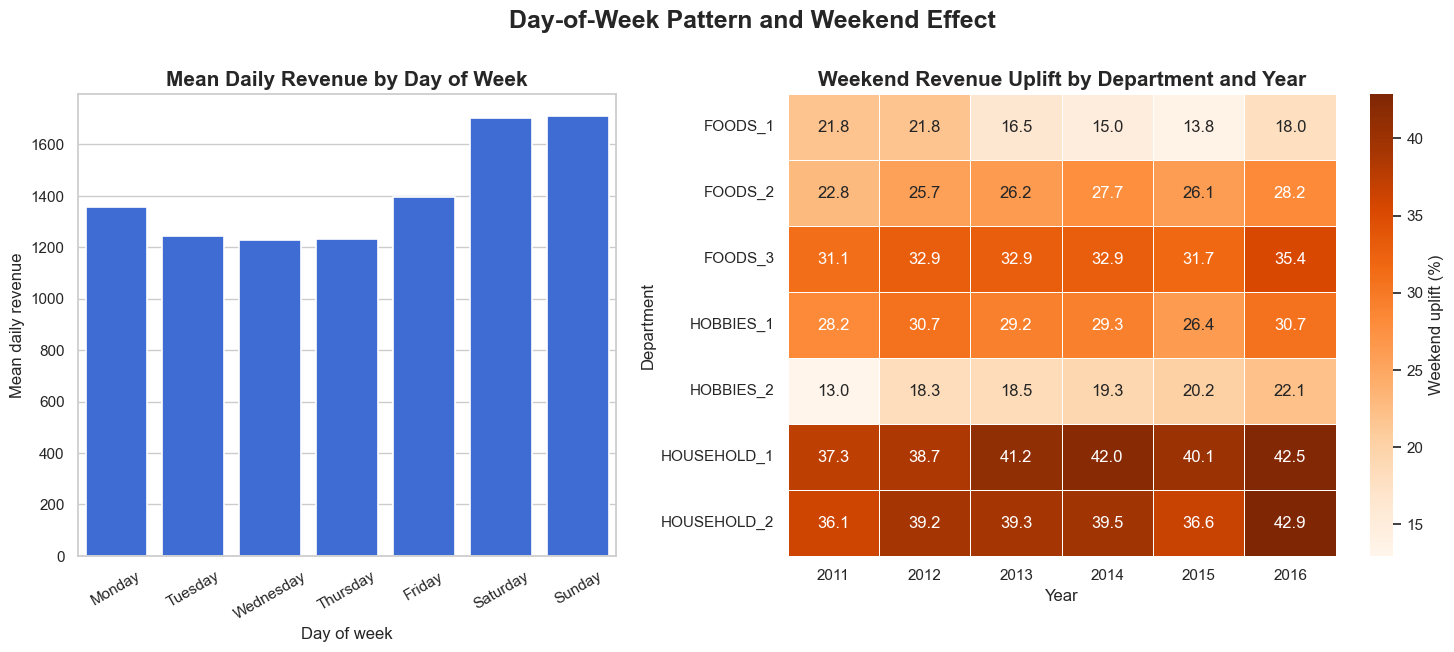

In [24]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["day_of_week_num"] = df["date"].dt.dayofweek
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["day_of_week_num"].isin([5, 6]).astype(int)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]
dow_summary = (
    df.groupby("day_of_week", as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"))
)

dow_summary["day_of_week"] = pd.Categorical(
    dow_summary["day_of_week"],
    categories=weekday_order,
    ordered=True
)

dow_summary = dow_summary.sort_values("day_of_week")

dept_year_weekend = (
    df.groupby(["year", "dept_id", "is_weekend"], as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"))
)

dept_year_weekend_pivot = dept_year_weekend.pivot_table(
    index=["year", "dept_id"],
    columns="is_weekend",
    values="mean_revenue"
).reset_index()

dept_year_weekend_pivot.columns = [
    "year", "dept_id", "weekday_mean", "weekend_mean"
]

dept_year_weekend_pivot["weekend_uplift_pct"] = (
    (dept_year_weekend_pivot["weekend_mean"] - dept_year_weekend_pivot["weekday_mean"])
    / dept_year_weekend_pivot["weekday_mean"] * 100
)

heatmap_data = dept_year_weekend_pivot.pivot(
    index="dept_id",
    columns="year",
    values="weekend_uplift_pct"
)

dept_order = ["FOODS_1", "FOODS_2", "FOODS_3", "HOBBIES_1", "HOBBIES_2", "HOUSEHOLD_1", "HOUSEHOLD_2"]
heatmap_data = heatmap_data.reindex(dept_order)

sns.set_theme(style="whitegrid", context="notebook")

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.4], wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])

sns.barplot(
    data=dow_summary,
    x="day_of_week",
    y="mean_revenue",
    color="#2563EB",
    edgecolor="white",
    linewidth=1.2,
    ax=ax1
)

ax1.set_title("Mean Daily Revenue by Day of Week", fontsize=15, fontweight="bold")
ax1.set_xlabel("Day of week")
ax1.set_ylabel("Mean daily revenue")
ax1.tick_params(axis="x", rotation=30)

ax2 = fig.add_subplot(gs[0, 1])

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Oranges",
    linewidths=0.5,
    ax=ax2,
    cbar_kws={"label": "Weekend uplift (%)"}
)

ax2.set_title("Weekend Revenue Uplift by Department and Year", fontsize=15, fontweight="bold")
ax2.set_xlabel("Year")
ax2.set_ylabel("Department")

fig.suptitle(
    "Day-of-Week Pattern and Weekend Effect",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

**Insight**

- Phân tích doanh thu theo thời gian cho thấy tổng doanh thu có xu hướng tăng rõ rệt trong giai đoạn 2011–2016. Đường trung bình trượt 28 ngày tăng dần theo thời gian, cho thấy dữ liệu tồn tại trend dài hạn thay vì chỉ dao động ngẫu nhiên. Vì vậy, yếu tố thời gian có khả năng mang thông tin quan trọng cho bài toán dự báo doanh thu.

- Khi phân tích theo tháng và department, kết quả cho thấy sự khác biệt giữa các department rõ ràng hơn sự khác biệt giữa các tháng. `FOODS_3` luôn duy trì mức doanh thu trung bình cao nhất ở hầu hết các tháng, trong khi `HOBBIES_2` có doanh thu thấp nhất. Điều này cho thấy seasonality theo tháng có tồn tại, nhưng không mạnh bằng ảnh hưởng của nhóm sản phẩm.

- Doanh thu cũng có pattern rõ theo ngày trong tuần. Saturday và Sunday có doanh thu trung bình cao hơn các ngày còn lại, cho thấy hành vi mua sắm cuối tuần là một pattern quan trọng trong dữ liệu bán lẻ.

- Phân tích weekend uplift theo department và year cho thấy weekend effect xuất hiện ở tất cả department và ổn định qua nhiều năm. Tuy nhiên, mức tăng không đồng đều giữa các nhóm sản phẩm. `HOUSEHOLD_1`, `HOUSEHOLD_2` và `FOODS_3` là các department có mức tăng doanh thu cuối tuần cao nhất.

**Kết luận**

- Từ các insight trên, các biến `year`, `month`, `day_of_week` và `is_weekend` được giữ lại làm feature candidate cho mô hình. Các biến này phản ánh trend dài hạn, seasonality theo tháng và hành vi mua sắm khác nhau giữa ngày thường và cuối tuần.

- Ngoài ra, do weekend effect khác nhau theo department, interaction feature `dept_weekend` cũng được xem là một feature candidate hợp lý. Tuy nhiên, feature này chưa được kết luận là feature cuối cùng ở bước EDA, mà cần được kiểm thử thêm bằng LightGBM ablation trong giai đoạn modeling.


# 7. Event Và SNAP Analysis

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

# Event features
df["is_event_day"] = (
    df["event_name_1"].notna() | df["event_name_2"].notna()
).astype(int)

df["event_type_main"] = (
    df["event_type_1"]
    .fillna(df["event_type_2"])
    .fillna("No Event")
)

df["event_name_main"] = (
    df["event_name_1"]
    .fillna(df["event_name_2"])
    .fillna("No Event")
)

# SNAP label
df["snap_label"] = df["snap_active"].map({
    0: "Non-SNAP",
    1: "SNAP active"
})

# Department order
dept_order = [
    "FOODS_1", "FOODS_2", "FOODS_3",
    "HOBBIES_1", "HOBBIES_2",
    "HOUSEHOLD_1", "HOUSEHOLD_2"
]

display(
    df[[
        "date", "dept_id", "cat_id", "daily_revenue",
        "event_name_1", "event_type_1",
        "event_name_2", "event_type_2",
        "is_event_day", "event_type_main",
        "snap_active", "snap_label"
    ]].head()
)

,date,dept_id,cat_id,daily_revenue,event_name_1,event_type_1,event_name_2,event_type_2,is_event_day,event_type_main,snap_active,snap_label
0,2011-01-29,FOODS_1,FOODS,681.1800,No Event,No Event,No Event,No Event,1,No Event,0,Non-SNAP
1,2011-01-29,FOODS_2,FOODS,"2,236.0100",No Event,No Event,No Event,No Event,1,No Event,0,Non-SNAP
2,2011-01-29,FOODS_3,FOODS,"4,323.4600",No Event,No Event,No Event,No Event,1,No Event,0,Non-SNAP
3,2011-01-29,HOBBIES_1,HOBBIES,"1,276.8600",No Event,No Event,No Event,No Event,1,No Event,0,Non-SNAP
4,2011-01-29,HOBBIES_2,HOBBIES,93.0500,No Event,No Event,No Event,No Event,1,No Event,0,Non-SNAP


,event_type_main,rows,mean_revenue,median_revenue,total_revenue,row_share_pct,revenue_share_pct
4,Sporting,1120,"1,440.0270",996.2450,"1,612,830.2718",0.8243,0.8419
0,Cultural,2590,"1,435.3638",999.2350,"3,717,592.3509",1.9062,1.9405
3,Religious,3780,"1,416.6783",998.0350,"5,355,043.9515",2.7821,2.7952
2,No Event,124810,"1,414.8775",990.6700,"176,590,863.1861",91.8599,92.1772
1,National,3570,"1,204.8225",738.4700,"4,301,216.3543",2.6275,2.2452


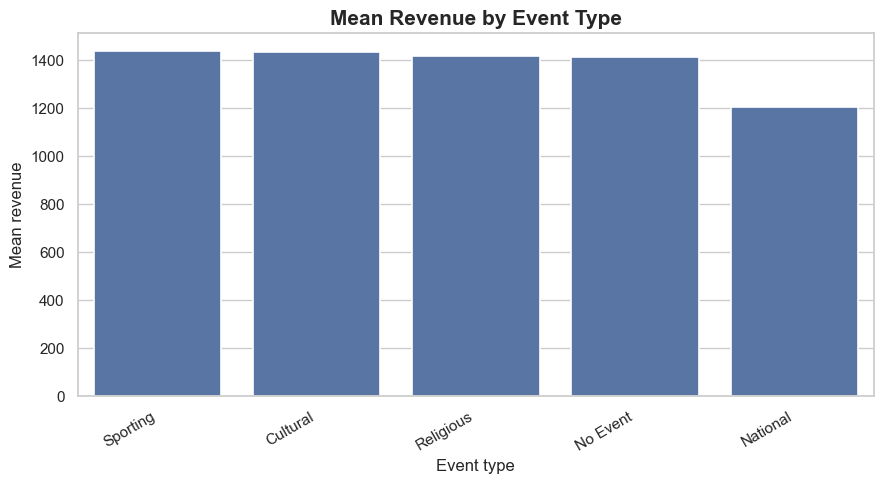

In [26]:
event_type_summary = (
    df.groupby("event_type_main", as_index=False)
    .agg(
        rows=("daily_revenue", "size"),
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median"),
        total_revenue=("daily_revenue", "sum")
    )
    .sort_values("mean_revenue", ascending=False)
)

event_type_summary["row_share_pct"] = event_type_summary["rows"] / len(df) * 100
event_type_summary["revenue_share_pct"] = (
    event_type_summary["total_revenue"] / df["daily_revenue"].sum() * 100
)

display(event_type_summary)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=event_type_summary,
    x="event_type_main",
    y="mean_revenue",
    edgecolor="white",
    linewidth=1.2
)

ax.set_title("Mean Revenue by Event Type", fontsize=15, fontweight="bold")
ax.set_xlabel("Event type")
ax.set_ylabel("Mean revenue")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

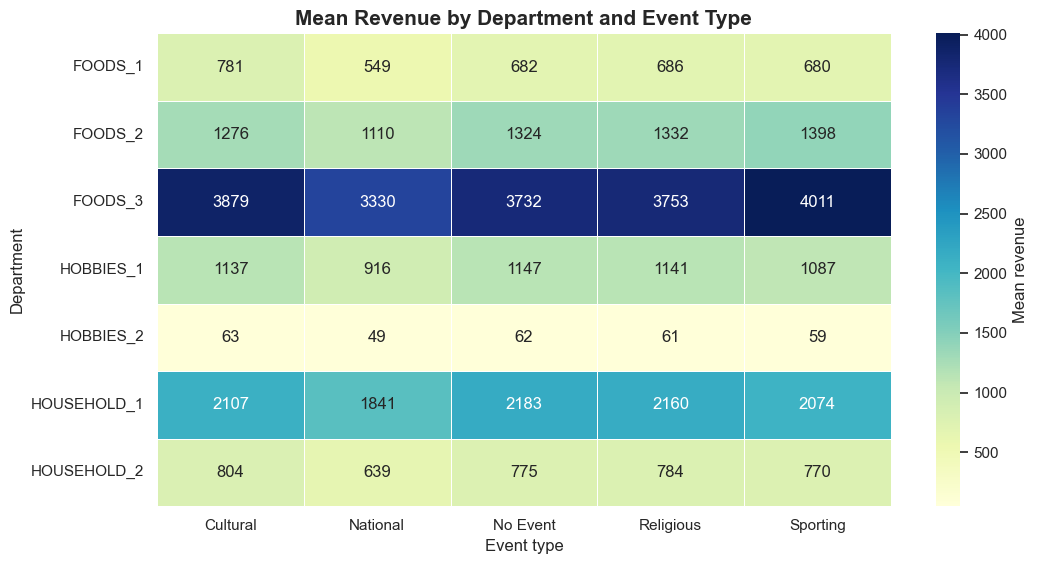

In [27]:
dept_event_type = (
    df.groupby(["dept_id", "event_type_main"], as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"))
)

dept_event_type_pivot = dept_event_type.pivot(
    index="dept_id",
    columns="event_type_main",
    values="mean_revenue"
)

dept_event_type_pivot = dept_event_type_pivot.reindex(dept_order)

plt.figure(figsize=(11, 5.8))

ax = sns.heatmap(
    dept_event_type_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Mean revenue"}
)

ax.set_title(
    "Mean Revenue by Department and Event Type",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Event type")
ax.set_ylabel("Department")

plt.tight_layout()
plt.show()

,event_name_main,event_type_main,rows,mean_revenue,median_revenue,approx_event_days
1,Christmas,National,350,0.4325,0.0000,5.0000
27,Thanksgiving,National,350,833.3153,501.5250,5.0000
18,NewYear,National,350,"1,070.8065",773.6150,5.0000
12,LentWeek2,Religious,420,"1,219.3548",900.3000,6.0000
8,Halloween,Cultural,350,"1,248.2849",891.7650,5.0000
17,NBAFinalsStart,Sporting,350,"1,261.9887",916.0500,5.0000
11,LentStart,Religious,420,"1,263.9231",972.4850,6.0000
9,IndependenceDay,National,350,"1,309.8862",844.0750,5.0000
16,NBAFinalsEnd,Sporting,350,"1,337.4474","1,010.4950",5.0000
19,OrthodoxChristmas,Religious,350,"1,357.1269",985.5700,5.0000


,event_name_main,event_type_main,rows,mean_revenue,median_revenue,approx_event_days
2,Cinco De Mayo,Cultural,350,"1,434.9423",984.3400,5.0000
22,PresidentsDay,National,420,"1,442.5437",991.4350,6.0000
3,ColumbusDay,National,350,"1,457.2238",973.6450,5.0000
23,Purim End,Religious,420,"1,492.7357","1,067.9100",6.0000
15,Mother's day,Cultural,420,"1,511.0453","1,042.1400",6.0000
21,Pesach End,Religious,420,"1,512.1993","1,015.0800",6.0000
4,Easter,Cultural,350,"1,641.6133","1,068.6900",5.0000
26,SuperBowl,Sporting,420,"1,673.8753","1,097.9500",6.0000
10,LaborDay,National,350,"1,683.1016","1,158.8650",5.0000
20,OrthodoxEaster,Religious,350,"1,770.7303","1,164.3400",5.0000


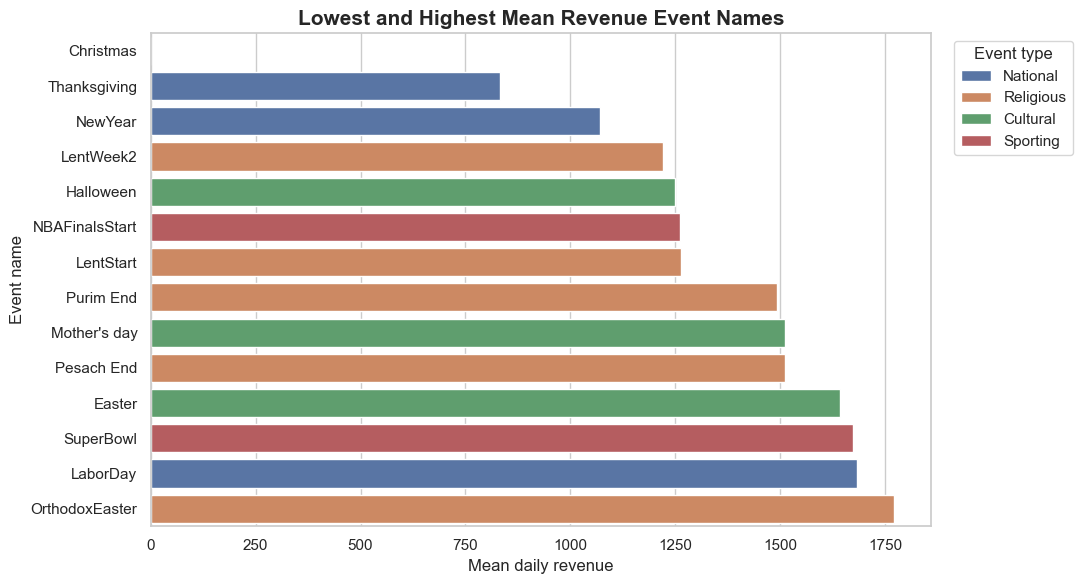

In [28]:
event_name_summary = (
    df[df["event_name_main"] != "No Event"]
    .groupby(["event_name_main", "event_type_main"], as_index=False)
    .agg(
        rows=("daily_revenue", "size"),
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median")
    )
)

# Ước lượng số ngày event dựa trên số chuỗi store-department
store_dept_count = df[["store_id", "dept_id"]].drop_duplicates().shape[0]
event_name_summary["approx_event_days"] = (
    event_name_summary["rows"] / store_dept_count
)

event_name_summary = event_name_summary.sort_values("mean_revenue")

display(event_name_summary.head(10))
display(event_name_summary.tail(10))

event_plot = pd.concat([
    event_name_summary.head(7),
    event_name_summary.tail(7)
])

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=event_plot,
    x="mean_revenue",
    y="event_name_main",
    hue="event_type_main",
    dodge=False
)

ax.set_title(
    "Lowest and Highest Mean Revenue Event Names",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mean daily revenue")
ax.set_ylabel("Event name")

plt.legend(
    title="Event type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

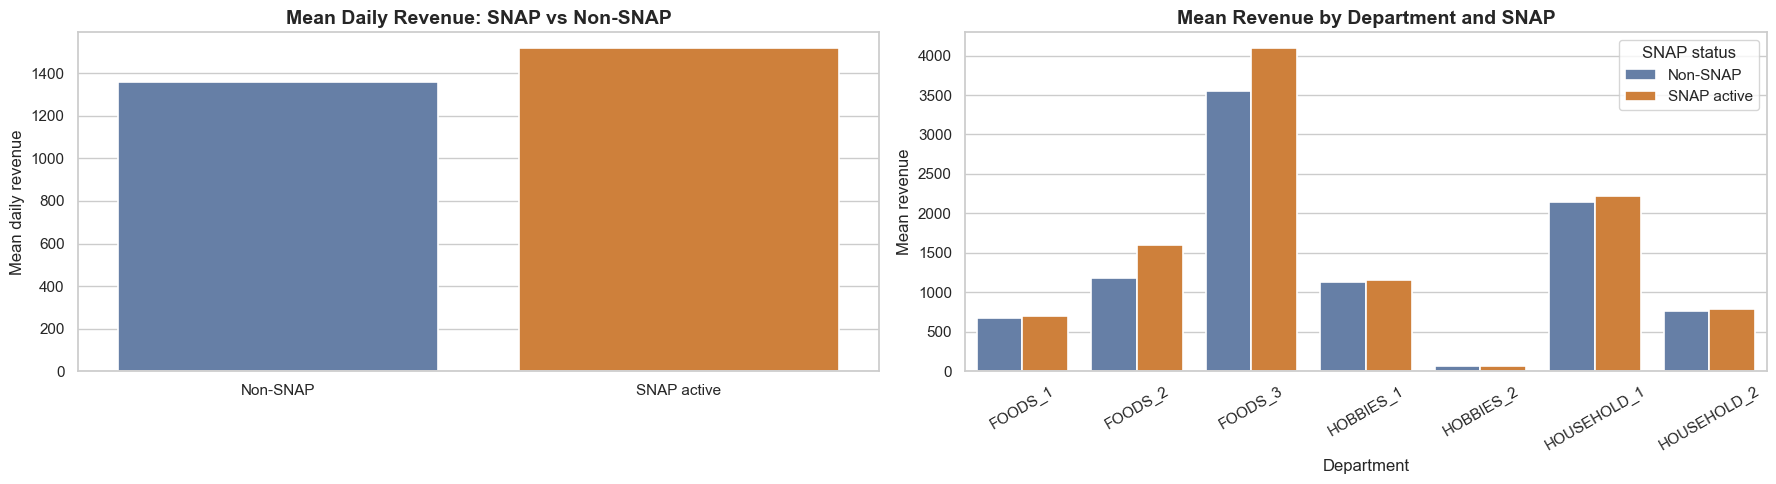

In [29]:
# Tạo label rõ ràng cho SNAP
df["snap_label"] = df["snap_active"].map({
    0: "Non-SNAP",
    1: "SNAP active"
})

# Summary tổng thể SNAP
snap_summary = (
    df.groupby("snap_label", as_index=False)
    .agg(
        rows=("daily_revenue", "size"),
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median"),
        total_revenue=("daily_revenue", "sum")
    )
)

# Sắp xếp thứ tự hiển thị
snap_order = ["Non-SNAP", "SNAP active"]
snap_summary["snap_label"] = pd.Categorical(
    snap_summary["snap_label"],
    categories=snap_order,
    ordered=True
)
snap_summary = snap_summary.sort_values("snap_label")

# display(snap_summary)

# Summary theo department và SNAP
dept_snap_summary_plot = (
    df.groupby(["dept_id", "snap_label"], as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"))
)

dept_order = [
    "FOODS_1", "FOODS_2", "FOODS_3",
    "HOBBIES_1", "HOBBIES_2",
    "HOUSEHOLD_1", "HOUSEHOLD_2"
]

dept_snap_summary_plot["dept_id"] = pd.Categorical(
    dept_snap_summary_plot["dept_id"],
    categories=dept_order,
    ordered=True
)

dept_snap_summary_plot["snap_label"] = pd.Categorical(
    dept_snap_summary_plot["snap_label"],
    categories=snap_order,
    ordered=True
)

dept_snap_summary_plot = dept_snap_summary_plot.sort_values(
    ["dept_id", "snap_label"]
)

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Biểu đồ 1: SNAP vs Non-SNAP
sns.barplot(
    data=snap_summary,
    x="snap_label",
    y="mean_revenue",
    hue="snap_label",
    hue_order=snap_order,
    palette={
        "Non-SNAP": "#5B7DB1",
        "SNAP active": "#E67E22"
    },
    edgecolor="white",
    linewidth=1.2,
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Mean Daily Revenue: SNAP vs Non-SNAP",
    fontsize=14,
    fontweight="bold"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean daily revenue")

# Biểu đồ 2: Department x SNAP
sns.barplot(
    data=dept_snap_summary_plot,
    x="dept_id",
    y="mean_revenue",
    hue="snap_label",
    hue_order=snap_order,
    palette={
        "Non-SNAP": "#5B7DB1",
        "SNAP active": "#E67E22"
    },
    edgecolor="white",
    linewidth=1.2,
    ax=axes[1]
)

axes[1].set_title(
    "Mean Revenue by Department and SNAP",
    fontsize=14,
    fontweight="bold"
)
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Mean revenue")
axes[1].tick_params(axis="x", rotation=30)

axes[1].legend(
    title="SNAP status",
    loc="upper right"
)

plt.tight_layout()
plt.show()

,dept_id,non_snap_mean,snap_mean,snap_uplift,snap_uplift_pct
1,FOODS_2,"1,182.4728","1,595.0617",412.5889,34.8920
2,FOODS_3,"3,548.8672","4,089.8597",540.9925,15.2441
0,FOODS_1,668.7038,703.4312,34.7273,5.1932
5,HOUSEHOLD_1,"2,146.6905","2,219.4273",72.7367,3.3883
3,HOBBIES_1,"1,129.7226","1,159.7739",30.0513,2.6601
6,HOUSEHOLD_2,766.1346,783.7011,17.5666,2.2929
4,HOBBIES_2,61.7882,62.1149,0.3267,0.5287


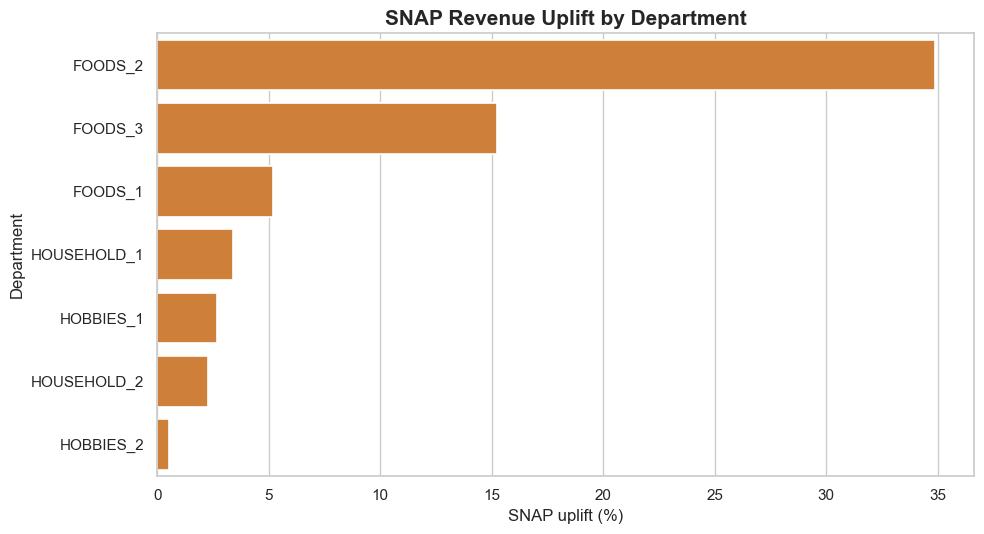

In [30]:
dept_snap_summary = (
    df.groupby(["dept_id", "snap_active"], as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"))
)

dept_snap_pivot = dept_snap_summary.pivot(
    index="dept_id",
    columns="snap_active",
    values="mean_revenue"
).reset_index()

dept_snap_pivot.columns = ["dept_id", "non_snap_mean", "snap_mean"]

dept_snap_pivot["snap_uplift"] = (
    dept_snap_pivot["snap_mean"] - dept_snap_pivot["non_snap_mean"]
)

dept_snap_pivot["snap_uplift_pct"] = (
    dept_snap_pivot["snap_uplift"] / dept_snap_pivot["non_snap_mean"] * 100
)

dept_snap_pivot = dept_snap_pivot.sort_values("snap_uplift_pct", ascending=False)

display(dept_snap_pivot)

plt.figure(figsize=(10, 5.5))

ax = sns.barplot(
    data=dept_snap_pivot,
    x="snap_uplift_pct",
    y="dept_id",
    color="#E67E22",
    edgecolor="white",
    linewidth=1.2
)

ax.set_title("SNAP Revenue Uplift by Department", fontsize=15, fontweight="bold")
ax.set_xlabel("SNAP uplift (%)")
ax.set_ylabel("Department")

plt.tight_layout()
plt.show()

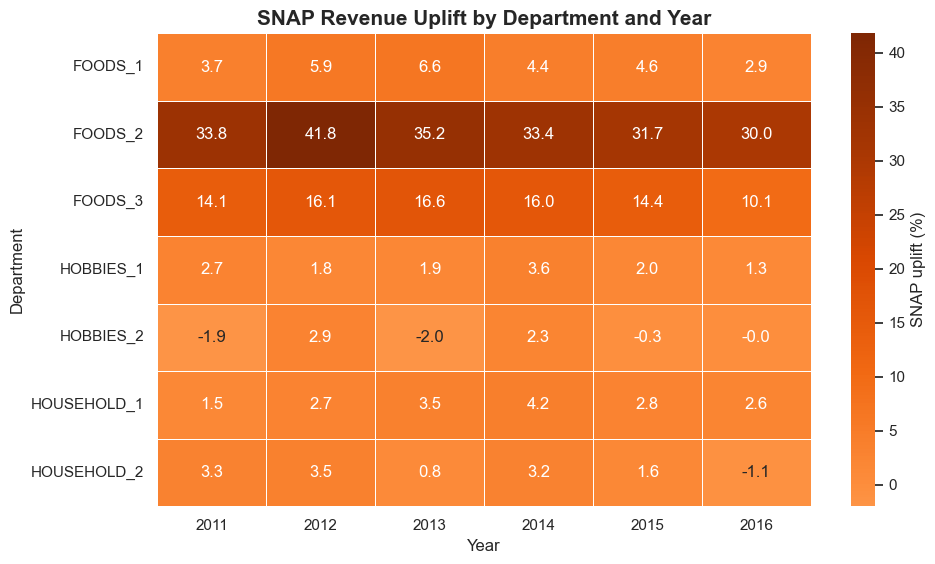

In [31]:
dept_year_snap = (
    df.groupby(["year", "dept_id", "snap_active"], as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"))
)

dept_year_snap_pivot = dept_year_snap.pivot_table(
    index=["year", "dept_id"],
    columns="snap_active",
    values="mean_revenue"
).reset_index()

dept_year_snap_pivot.columns = [
    "year", "dept_id", "non_snap_mean", "snap_mean"
]

dept_year_snap_pivot["snap_uplift_pct"] = (
    (dept_year_snap_pivot["snap_mean"] - dept_year_snap_pivot["non_snap_mean"])
    / dept_year_snap_pivot["non_snap_mean"] * 100
)

snap_heatmap = dept_year_snap_pivot.pivot(
    index="dept_id",
    columns="year",
    values="snap_uplift_pct"
)

snap_heatmap = snap_heatmap.reindex(dept_order)

plt.figure(figsize=(10, 5.8))

ax = sns.heatmap(
    snap_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Oranges",
    linewidths=0.5,
    center=0,
    cbar_kws={"label": "SNAP uplift (%)"}
)

ax.set_title(
    "SNAP Revenue Uplift by Department and Year",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Department")

plt.tight_layout()
plt.show()

**Insight**: 

- Phân tích event cho thấy doanh thu có sự khác biệt giữa các loại event, trong đó nhóm National có doanh thu trung bình thấp hơn ở hầu hết các department. Khi phân tích chi tiết theo event name, mức giảm này chủ yếu đến từ một số ngày đặc biệt như Christmas, Thanksgiving và NewYear. Điều này cho thấy event effect không đồng đều giữa các ngày lễ, và event name có thể mang thông tin chi tiết hơn event type tổng quát.

- Đối với SNAP, doanh thu trong các ngày SNAP active cao hơn so với Non-SNAP, nhưng tác động này không phân bố đều giữa các nhóm sản phẩm. SNAP uplift tập trung mạnh ở nhóm FOODS, đặc biệt là FOODS_2 và FOODS_3, đồng thời pattern này ổn định qua nhiều năm. Các department còn lại chỉ tăng nhẹ hoặc gần như không thay đổi.

**Kết luận**

Từ các insight trên, snap_active được giữ làm feature candidate quan trọng. Do SNAP effect khác nhau rõ theo department, interaction dept_snap cũng được xem là feature candidate cần kiểm thử bằng LightGBM ablation. Đối với event, is_event_day, event_type_main, event_name_main và các flag cho ngày lễ đặc biệt như is_christmas, is_thanksgiving, is_newyear có thể được tạo và kiểm chứng thêm trong giai đoạn modeling.

# 8. Weather EDA

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

df["date"] = pd.to_datetime(df["date"])

weather_numeric_cols = [
    "temperature_max_c",
    "temperature_min_c",
    "temperature_mean_c",
    "apparent_temperature_mean_c",
    "precipitation_mm",
    "rain_mm",
    "snowfall_cm",
    "wind_speed_max_kmh",
    "wind_gusts_max_kmh",
    "shortwave_radiation_mj_m2",
]

weather_meta_cols = [
    "weather_location_id",
    "location_name",
    "weather_spatial_level",
    "weather_code",
    "weather_source"
]

weather_existing_cols = [col for col in weather_numeric_cols + weather_meta_cols if col in df.columns]
weather_missing_cols = [col for col in weather_numeric_cols + weather_meta_cols if col not in df.columns]

print("Existing weather columns:")
print(weather_existing_cols)

print("\nMissing weather columns:")
print(weather_missing_cols)

display(df[weather_existing_cols].head())

display(
    df[weather_numeric_cols]
    .describe()
    .T
)

display(
    df[weather_numeric_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_pct")
)

Existing weather columns:
['temperature_max_c', 'temperature_min_c', 'temperature_mean_c', 'apparent_temperature_mean_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm', 'wind_speed_max_kmh', 'wind_gusts_max_kmh', 'shortwave_radiation_mj_m2', 'weather_location_id', 'location_name', 'weather_spatial_level', 'weather_code', 'weather_source']

Missing weather columns:
[]


,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2,weather_location_id,location_name,weather_spatial_level,weather_code,weather_source
0,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,m5_CA,"Los Angeles, CA",state_representative_city,3,open_meteo_archive
1,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,m5_CA,"Los Angeles, CA",state_representative_city,3,open_meteo_archive
2,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,m5_CA,"Los Angeles, CA",state_representative_city,3,open_meteo_archive
3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,m5_CA,"Los Angeles, CA",state_representative_city,3,open_meteo_archive
4,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,m5_CA,"Los Angeles, CA",state_representative_city,3,open_meteo_archive


,count,mean,std,min,25%,50%,75%,max
temperature_max_c,"135,870.0000",20.8922,10.7769,-17.6000,14.7000,22.7000,28.8000,42.4000
temperature_min_c,"135,870.0000",11.1111,9.0944,-25.3000,5.8000,11.6000,17.5000,31.7000
temperature_mean_c,"135,870.0000",15.7061,9.6775,-22.9000,10.2000,16.8000,22.5000,37.2000
apparent_temperature_mean_c,"135,870.0000",14.1394,11.8188,-31.4000,7.1000,15.2000,22.5000,38.6000
precipitation_mm,"135,870.0000",1.6959,5.7740,0.0000,0.0000,0.0000,0.3000,85.5000
rain_mm,"135,870.0000",1.6000,5.6768,0.0000,0.0000,0.0000,0.2000,85.5000
snowfall_cm,"135,870.0000",0.0731,0.6062,0.0000,0.0000,0.0000,0.0000,14.6300
wind_speed_max_kmh,"135,870.0000",17.9260,7.0786,4.7000,12.6000,15.8000,22.6000,48.5000
wind_gusts_max_kmh,"135,870.0000",36.3685,11.4138,10.4000,28.8000,34.2000,42.1000,93.6000
shortwave_radiation_mj_m2,"135,870.0000",17.7210,7.7816,0.5400,11.9600,17.7300,24.3300,31.5700


,missing_pct
temperature_max_c,0.0000
temperature_min_c,0.0000
temperature_mean_c,0.0000
apparent_temperature_mean_c,0.0000
precipitation_mm,0.0000
rain_mm,0.0000
snowfall_cm,0.0000
wind_speed_max_kmh,0.0000
wind_gusts_max_kmh,0.0000
shortwave_radiation_mj_m2,0.0000


In [33]:
df_weather = df.copy()
df_weather["date"] = pd.to_datetime(df_weather["date"])
df_weather["year"] = df_weather["date"].dt.year
df_weather["month"] = df_weather["date"].dt.month

# Revenue index theo từng chuỗi store-department
df_weather["series_mean_revenue"] = (
    df_weather
    .groupby(["store_id", "dept_id"])["daily_revenue"]
    .transform("mean")
)

df_weather["revenue_index"] = (
    df_weather["daily_revenue"] / df_weather["series_mean_revenue"]
)

# Temperature bin
df_weather["temp_bin"] = pd.cut(
    df_weather["temperature_mean_c"],
    bins=[-np.inf, 0, 10, 20, 30, np.inf],
    labels=["Very cold", "Cold", "Mild", "Warm", "Hot"]
)

# Rain / precipitation bin
df_weather["rain_level"] = pd.cut(
    df_weather["precipitation_mm"],
    bins=[-0.01, 0, 2.5, 10, np.inf],
    labels=["No rain", "Light rain", "Moderate rain", "Heavy rain"]
)

# Wind bin
df_weather["wind_bin"] = pd.cut(
    df_weather["wind_speed_max_kmh"],
    bins=[-np.inf, 15, 30, 45, np.inf],
    labels=["Low wind", "Moderate wind", "Strong wind", "Very strong wind"]
)

# Extreme weather flags
df_weather["is_rain_day"] = (df_weather["precipitation_mm"] > 0).astype(int)
df_weather["is_heavy_rain"] = (df_weather["precipitation_mm"] > 10).astype(int)
df_weather["is_snow_day"] = (df_weather["snowfall_cm"] > 0).astype(int)
df_weather["is_very_cold_day"] = (df_weather["temperature_mean_c"] < 0).astype(int)
df_weather["is_hot_day"] = (df_weather["temperature_mean_c"] >= 30).astype(int)
df_weather["is_strong_wind"] = (df_weather["wind_speed_max_kmh"] >= 30).astype(int)

display(
    df_weather[
        [
            "temperature_mean_c", "temp_bin",
            "precipitation_mm", "rain_level",
            "snowfall_cm",
            "wind_speed_max_kmh", "wind_bin",
            "revenue_index"
        ]
    ].head()
)

,temperature_mean_c,temp_bin,precipitation_mm,rain_level,snowfall_cm,wind_speed_max_kmh,wind_bin,revenue_index
0,11.7000,Mild,0.0000,No rain,0.0000,10.9000,Low wind,0.9956
1,11.7000,Mild,0.0000,No rain,0.0000,10.9000,Low wind,1.4564
2,11.7000,Mild,0.0000,No rain,0.0000,10.9000,Low wind,0.9004
3,11.7000,Mild,0.0000,No rain,0.0000,10.9000,Low wind,0.7990
4,11.7000,Mild,0.0000,No rain,0.0000,10.9000,Low wind,1.4605


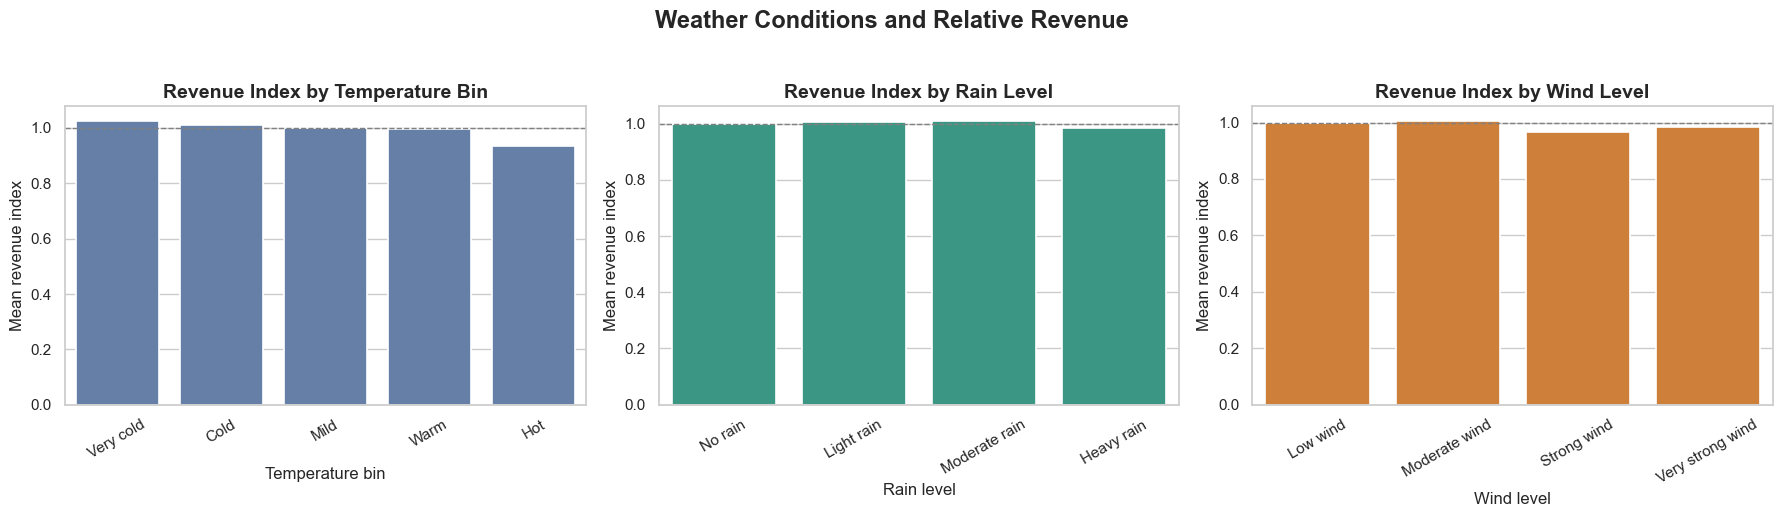

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# Temperature
# =========================
temp_summary = (
    df_weather
    .groupby("temp_bin", observed=True, as_index=False)
    .agg(
        mean_revenue_index=("revenue_index", "mean"),
        rows=("daily_revenue", "size")
    )
)

sns.barplot(
    data=temp_summary,
    x="temp_bin",
    y="mean_revenue_index",
    color="#5B7DB1",
    edgecolor="white",
    linewidth=1.2,
    ax=axes[0]
)

axes[0].axhline(1, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Revenue Index by Temperature Bin", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Temperature bin")
axes[0].set_ylabel("Mean revenue index")
axes[0].tick_params(axis="x", rotation=30)

# =========================
# Rain
# =========================
rain_summary = (
    df_weather
    .groupby("rain_level", observed=True, as_index=False)
    .agg(
        mean_revenue_index=("revenue_index", "mean"),
        rows=("daily_revenue", "size")
    )
)

sns.barplot(
    data=rain_summary,
    x="rain_level",
    y="mean_revenue_index",
    color="#2CA58D",
    edgecolor="white",
    linewidth=1.2,
    ax=axes[1]
)

axes[1].axhline(1, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Revenue Index by Rain Level", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Rain level")
axes[1].set_ylabel("Mean revenue index")
axes[1].tick_params(axis="x", rotation=30)

# =========================
# Wind
# =========================
wind_summary = (
    df_weather
    .groupby("wind_bin", observed=True, as_index=False)
    .agg(
        mean_revenue_index=("revenue_index", "mean"),
        rows=("daily_revenue", "size")
    )
)

sns.barplot(
    data=wind_summary,
    x="wind_bin",
    y="mean_revenue_index",
    color="#E67E22",
    edgecolor="white",
    linewidth=1.2,
    ax=axes[2]
)

axes[2].axhline(1, color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Revenue Index by Wind Level", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Wind level")
axes[2].set_ylabel("Mean revenue index")
axes[2].tick_params(axis="x", rotation=30)

fig.suptitle(
    "Weather Conditions and Relative Revenue",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

# display(temp_summary)
# display(rain_summary)
# display(wind_summary)

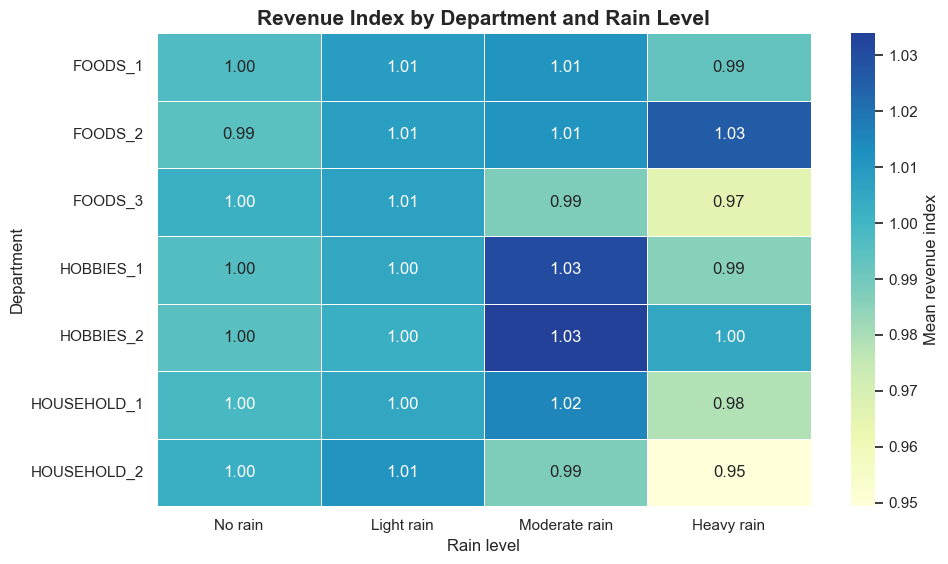

In [35]:
dept_order = [
    "FOODS_1", "FOODS_2", "FOODS_3",
    "HOBBIES_1", "HOBBIES_2",
    "HOUSEHOLD_1", "HOUSEHOLD_2"
]

dept_rain_summary = (
    df_weather
    .groupby(["dept_id", "rain_level"], observed=True, as_index=False)
    .agg(mean_revenue_index=("revenue_index", "mean"))
)

dept_rain_pivot = dept_rain_summary.pivot(
    index="dept_id",
    columns="rain_level",
    values="mean_revenue_index"
).reindex(dept_order)

plt.figure(figsize=(10, 5.8))

ax = sns.heatmap(
    dept_rain_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    center=1,
    cbar_kws={"label": "Mean revenue index"}
)

ax.set_title(
    "Revenue Index by Department and Rain Level",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Rain level")
ax.set_ylabel("Department")

plt.tight_layout()
plt.show()

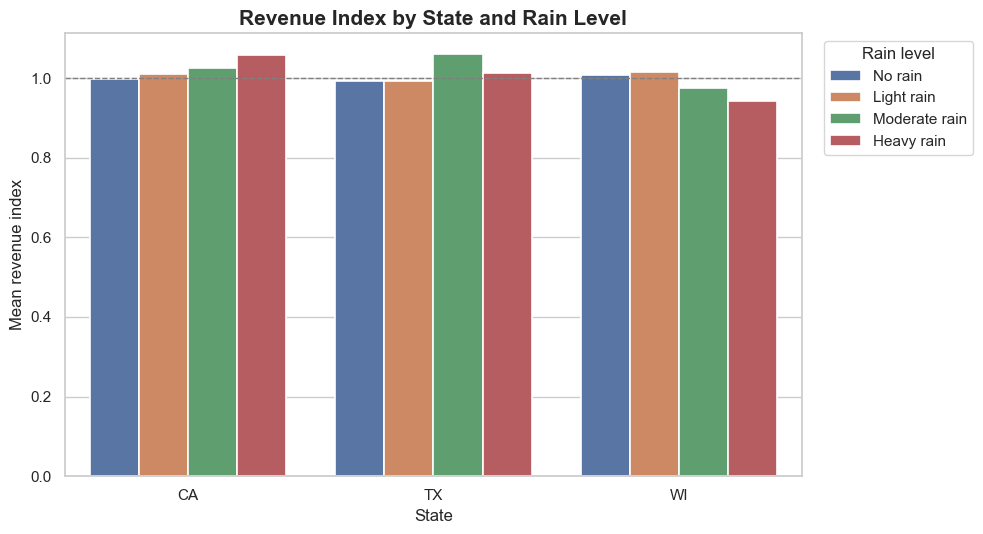

In [36]:
state_rain_summary = (
    df_weather
    .groupby(["state_id", "rain_level"], observed=True, as_index=False)
    .agg(mean_revenue_index=("revenue_index", "mean"))
)

plt.figure(figsize=(10, 5.5))

ax = sns.barplot(
    data=state_rain_summary,
    x="state_id",
    y="mean_revenue_index",
    hue="rain_level",
    edgecolor="white",
    linewidth=1.2
)

ax.axhline(1, color="gray", linestyle="--", linewidth=1)

ax.set_title(
    "Revenue Index by State and Rain Level",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("State")
ax.set_ylabel("Mean revenue index")
ax.legend(title="Rain level", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

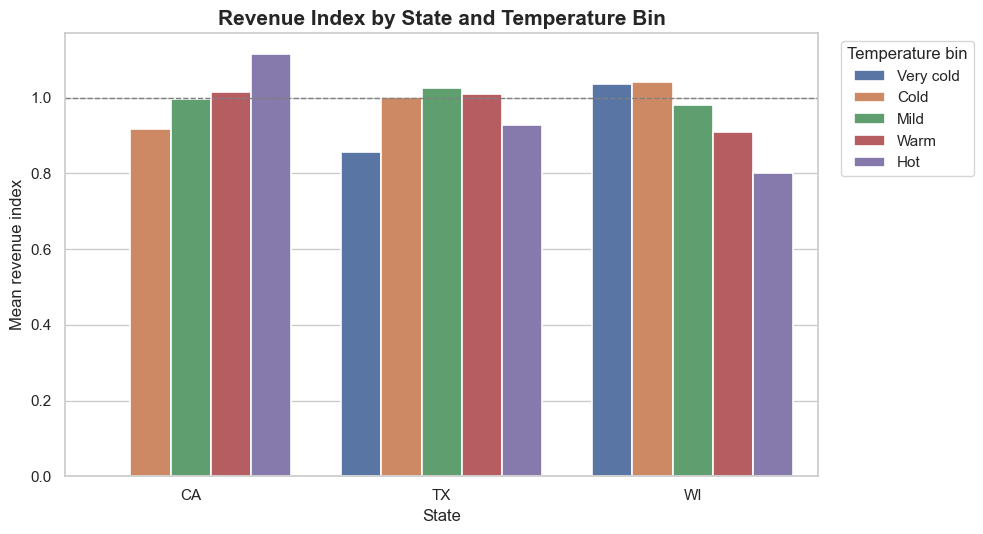

In [37]:
state_temp_summary = (
    df_weather
    .groupby(["state_id", "temp_bin"], observed=True, as_index=False)
    .agg(mean_revenue_index=("revenue_index", "mean"))
)

plt.figure(figsize=(10, 5.5))

ax = sns.barplot(
    data=state_temp_summary,
    x="state_id",
    y="mean_revenue_index",
    hue="temp_bin",
    edgecolor="white",
    linewidth=1.2
)

ax.axhline(1, color="gray", linestyle="--", linewidth=1)

ax.set_title(
    "Revenue Index by State and Temperature Bin",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("State")
ax.set_ylabel("Mean revenue index")
ax.legend(title="Temperature bin", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Insight**:

- Biểu đồ tổng quan cho thấy weather có tín hiệu liên quan đến doanh thu, nhưng mức ảnh hưởng nhìn chung không mạnh. Revenue index của hầu hết các nhóm thời tiết đều dao động quanh mức 1.0, cho thấy doanh thu tương đối gần với mức trung bình của từng chuỗi store-department. Tuy nhiên, một số điều kiện như Hot, Heavy rain và Strong wind có xu hướng làm revenue index giảm nhẹ.

- Khi phân tích theo rain level và department, tác động của mưa không đồng đều giữa các nhóm sản phẩm. Một số department như HOUSEHOLD_2 và FOODS_3 có revenue index thấp hơn trong điều kiện Heavy rain, trong khi một số department khác gần như không thay đổi hoặc thậm chí tăng nhẹ. Điều này cho thấy weather effect có thể phụ thuộc vào nhóm sản phẩm, nhưng mức chênh lệch nhìn chung vẫn nhỏ.

- Khi phân tích theo state và temperature bin, temperature effect cũng không đồng nhất giữa các khu vực. Đáng chú ý, nhóm Hot có revenue index thấp hơn rõ ở WI, trong khi pattern này không giống hoàn toàn ở các state còn lại. Điều này cho thấy tác động của weather có thể bị ảnh hưởng bởi yếu tố khu vực và mùa vụ.

**Kết luận**:

Từ các kết quả trên, các biến weather như temperature_mean_c, temp_bin, precipitation_mm, rain_level, is_heavy_rain, wind_speed_max_kmh và is_strong_wind được xem là feature candidate. Tuy nhiên, do weather effect tương đối yếu và không ổn định như các nhóm feature khác, cần kiểm chứng thêm bằng LightGBM ablation trước khi quyết định đưa vào feature set cuối cùng.

# 9. Kiểm định Weekend Effect

**Mục tiêu kiểm định**

Từ kết quả EDA, doanh thu vào cuối tuần có xu hướng cao hơn so với ngày thường. Để kiểm tra xem pattern này có cơ sở thống kê hay không, ta thực hiện kiểm định Weekend Effect.

Do dữ liệu có cấu trúc panel theo thời gian ở cấp `store_id × dept_id × date`, ta không so sánh trực tiếp từng dòng dữ liệu. Thay vào đó, doanh thu được tổng hợp theo từng nhóm `store_id × dept_id × year`, sau đó so sánh doanh thu trung bình giữa weekend và weekday trong cùng một nhóm.

**Giả thuyết kiểm định**

* **H0:** Doanh thu trung bình cuối tuần không cao hơn doanh thu trung bình ngày thường sau khi so sánh theo `store_id × dept_id × year`.
* **H1:** Doanh thu trung bình cuối tuần cao hơn doanh thu trung bình ngày thường sau khi so sánh theo `store_id × dept_id × year`.

Nếu p-value < 0.05, ta bác bỏ H0 và có đủ bằng chứng ủng hộ H1.


In [38]:
df_test = df.copy()

df_test["date"] = pd.to_datetime(df_test["date"])

df_test["year"] = df_test["date"].dt.year

df_test["is_weekend"] = (
    df_test["date"].dt.dayofweek.isin([5, 6])
).astype(int)

In [39]:
# Aggregate doanh thu trung bình theo từng store-dept-year-weekend
weekend_agg = (
    df_test
    .groupby(["store_id", "dept_id", "year", "is_weekend"], as_index=False)
    .agg(
        mean_revenue=("daily_revenue", "mean"),
        n_days=("daily_revenue", "size")
    )
)

# Pivot để mỗi dòng là một cặp weekday-weekend trong cùng store-dept-year
weekend_pivot = weekend_agg.pivot_table(
    index=["store_id", "dept_id", "year"],
    columns="is_weekend",
    values="mean_revenue"
).reset_index()

weekend_pivot.columns = [
    "store_id", "dept_id", "year", "weekday_mean", "weekend_mean"
]

# Chỉ giữ các nhóm có đủ weekday và weekend
weekend_pivot = weekend_pivot.dropna(subset=["weekday_mean", "weekend_mean"])

# Tính chênh lệch và uplift
weekend_pivot["diff"] = weekend_pivot["weekend_mean"] - weekend_pivot["weekday_mean"]

weekend_pivot["uplift_pct"] = (
    weekend_pivot["diff"] / weekend_pivot["weekday_mean"] * 100
)

display(weekend_pivot.head())

print("Number of paired groups:", len(weekend_pivot))

,store_id,dept_id,year,weekday_mean,weekend_mean,diff,uplift_pct
0,CA_1,FOODS_1,2011,440.8691,582.3741,141.5050,32.0968
1,CA_1,FOODS_1,2012,576.8979,766.4201,189.5222,32.8519
2,CA_1,FOODS_1,2013,650.0927,812.5738,162.4811,24.9935
3,CA_1,FOODS_1,2014,714.1811,885.4527,171.2716,23.9815
4,CA_1,FOODS_1,2015,752.1023,941.4345,189.3322,25.1737


Number of paired groups: 420


In [40]:
weekend_summary = pd.DataFrame({
    "metric": [
        "n_pairs",
        "weekday_mean_avg",
        "weekend_mean_avg",
        "mean_diff",
        "median_diff",
        "mean_uplift_pct",
        "median_uplift_pct"
    ],
    "value": [
        len(weekend_pivot),
        weekend_pivot["weekday_mean"].mean(),
        weekend_pivot["weekend_mean"].mean(),
        weekend_pivot["diff"].mean(),
        weekend_pivot["diff"].median(),
        weekend_pivot["uplift_pct"].mean(),
        weekend_pivot["uplift_pct"].median()
    ]
})

display(weekend_summary)

,metric,value
0,n_pairs,420.0000
1,weekday_mean_avg,"1,328.5707"
2,weekend_mean_avg,"1,760.6276"
3,mean_diff,432.0569
4,median_diff,276.8666
5,mean_uplift_pct,28.7500
6,median_uplift_pct,28.4198


In [41]:
# =========================
# Weekend Effect Test - Simplified
# =========================

from scipy import stats
import numpy as np
import pandas as pd

# 1. Paired t-test
t_stat, t_pvalue = stats.ttest_rel(
    weekend_pivot["weekend_mean"],
    weekend_pivot["weekday_mean"]
)

# 2. Effect size: Cohen's dz
cohen_dz = (
    weekend_pivot["diff"].mean()
    / weekend_pivot["diff"].std(ddof=1)
)

# 3. Summary metrics
n = len(weekend_pivot)

weekend_test_result = pd.DataFrame({
    "metric": [
        "n_pairs",
        "weekday_mean_avg",
        "weekend_mean_avg",
        "mean_diff",
        "mean_uplift_pct",
        "paired_t_pvalue",
        "cohen_dz"
    ],
    "value": [
        n,
        weekend_pivot["weekday_mean"].mean(),
        weekend_pivot["weekend_mean"].mean(),
        weekend_pivot["diff"].mean(),
        weekend_pivot["uplift_pct"].mean(),
        t_pvalue,
        cohen_dz
    ]
})

display(weekend_test_result)

,metric,value
0,n_pairs,420.0000
1,weekday_mean_avg,"1,328.5707"
2,weekend_mean_avg,"1,760.6276"
3,mean_diff,432.0569
4,mean_uplift_pct,28.7500
5,paired_t_pvalue,0.0000
6,cohen_dz,0.9272


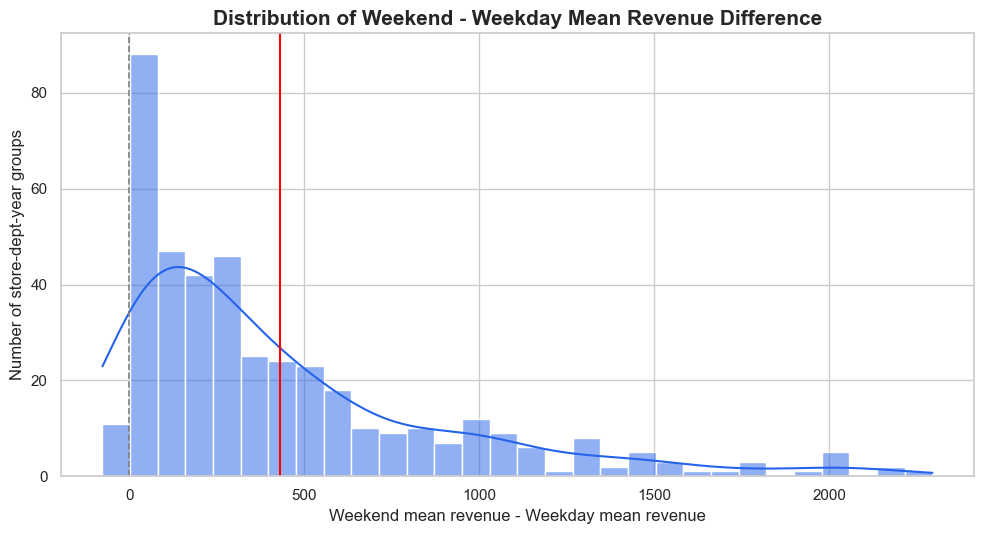

In [42]:
plt.figure(figsize=(10, 5.5))

ax = sns.histplot(
    weekend_pivot["diff"],
    bins=30,
    kde=True,
    color="#2563EB",
    edgecolor="white"
)

ax.axvline(0, color="gray", linestyle="--", linewidth=1.2)
ax.axvline(weekend_pivot["diff"].mean(), color="red", linestyle="-", linewidth=1.5)

ax.set_title(
    "Distribution of Weekend - Weekday Mean Revenue Difference",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Weekend mean revenue - Weekday mean revenue")
ax.set_ylabel("Number of store-dept-year groups")

plt.tight_layout()
plt.show()

,dept_id,mean_uplift_pct,median_uplift_pct,mean_diff,n_pairs
5,HOUSEHOLD_1,40.6297,38.4039,817.9711,60
6,HOUSEHOLD_2,36.6172,35.7618,276.9528,60
2,FOODS_3,32.8820,32.6851,"1,143.2210",60
3,HOBBIES_1,28.5764,29.6972,317.5804,60
1,FOODS_2,27.6952,24.3244,341.1242,60
4,HOBBIES_2,18.3318,15.2067,11.5138,60
0,FOODS_1,16.5178,15.0794,116.0348,60


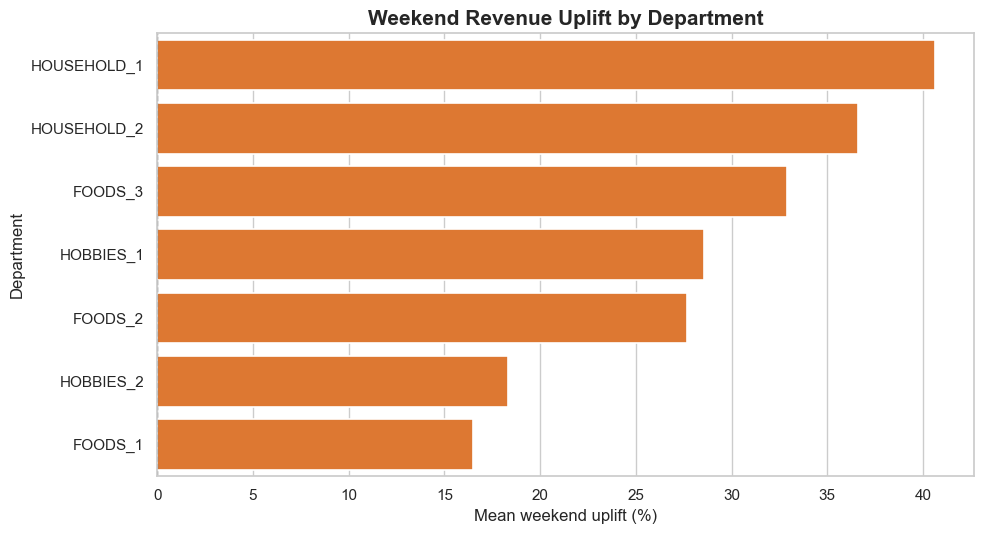

In [43]:
dept_weekend_uplift = (
    weekend_pivot
    .groupby("dept_id", as_index=False)
    .agg(
        mean_uplift_pct=("uplift_pct", "mean"),
        median_uplift_pct=("uplift_pct", "median"),
        mean_diff=("diff", "mean"),
        n_pairs=("diff", "size")
    )
    .sort_values("mean_uplift_pct", ascending=False)
)

display(dept_weekend_uplift)

plt.figure(figsize=(10, 5.5))

ax = sns.barplot(
    data=dept_weekend_uplift,
    x="mean_uplift_pct",
    y="dept_id",
    color="#F97316",
    edgecolor="white",
    linewidth=1.2
)

ax.axvline(0, color="gray", linestyle="--", linewidth=1)

ax.set_title(
    "Weekend Revenue Uplift by Department",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mean weekend uplift (%)")
ax.set_ylabel("Department")

plt.tight_layout()
plt.show()

**Kết luận kiểm định**

- Với mức ý nghĩa 5%, kết quả kiểm định cho thấy có đủ bằng chứng để bác bỏ giả thuyết H0 và ủng hộ giả thuyết H1. Điều này có nghĩa là doanh thu cuối tuần cao hơn doanh thu ngày thường sau khi đã so sánh theo từng nhóm store_id × dept_id × year.

- Cụ thể, doanh thu trung bình ngày thường là khoảng 1,328.57, trong khi doanh thu trung bình cuối tuần là khoảng 1,760.63. Mức chênh lệch trung bình khoảng 432.06, tương ứng với weekend uplift khoảng 28.75%.

- Vì vậy, có thể kết luận rằng weekend effect là một pattern có ý nghĩa trong dữ liệu. Biến is_weekend được giữ làm feature candidate cho mô hình, và interaction dept_weekend cũng được xem xét kiểm thử thêm trong giai đoạn modeling.

# 10. Kiểm định SNAP Effect

Sau EDA, doanh thu trong các ngày `SNAP active` có xu hướng cao hơn so với các ngày `Non-SNAP`. Để kiểm tra pattern này có cơ sở thống kê hay không, ta thực hiện kiểm định SNAP effect.

Do dữ liệu có cấu trúc panel time series ở cấp `store_id × dept_id × date`, ta aggregate doanh thu trung bình theo từng nhóm `store_id × dept_id × year`, sau đó so sánh doanh thu trung bình giữa ngày `SNAP active` và ngày `Non-SNAP` trong cùng một nhóm.

Giả thuyết kiểm định:

- **H0:** Doanh thu trung bình ngày `SNAP active` không cao hơn ngày `Non-SNAP`.
- **H1:** Doanh thu trung bình ngày `SNAP active` cao hơn ngày `Non-SNAP`.

Nếu p-value < 0.05, ta bác bỏ H0 và có đủ bằng chứng ủng hộ H1.

In [44]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Copy dữ liệu
df_test = df.copy()
df_test["date"] = pd.to_datetime(df_test["date"])
df_test["year"] = df_test["date"].dt.year

# Kiểm tra biến snap_active
display(df_test["snap_active"].value_counts().to_frame("count"))

# Aggregate doanh thu trung bình theo store-dept-year-snap
snap_agg = (
    df_test
    .groupby(["store_id", "dept_id", "year", "snap_active"], as_index=False)
    .agg(
        mean_revenue=("daily_revenue", "mean"),
        n_days=("daily_revenue", "size")
    )
)

# Pivot để mỗi dòng là một cặp Non-SNAP và SNAP trong cùng store-dept-year
snap_pivot = snap_agg.pivot_table(
    index=["store_id", "dept_id", "year"],
    columns="snap_active",
    values="mean_revenue"
).reset_index()

snap_pivot.columns = [
    "store_id", "dept_id", "year", "non_snap_mean", "snap_mean"
]

# Chỉ giữ nhóm có đủ Non-SNAP và SNAP
snap_pivot = snap_pivot.dropna(subset=["non_snap_mean", "snap_mean"])

# Tính chênh lệch và uplift
snap_pivot["diff"] = snap_pivot["snap_mean"] - snap_pivot["non_snap_mean"]

snap_pivot["uplift_pct"] = (
    snap_pivot["diff"] / snap_pivot["non_snap_mean"] * 100
)

display(snap_pivot.head())

print("Number of paired groups:", len(snap_pivot))

,count
snap_active,
0,91070
1,44800


,store_id,dept_id,year,non_snap_mean,snap_mean,diff,uplift_pct
0,CA_1,FOODS_1,2011,480.3952,484.0834,3.6882,0.7677
1,CA_1,FOODS_1,2012,626.8705,640.2859,13.4154,2.1401
2,CA_1,FOODS_1,2013,703.1151,682.6557,-20.4594,-2.9098
3,CA_1,FOODS_1,2014,764.8021,759.2653,-5.5369,-0.7240
4,CA_1,FOODS_1,2015,795.6562,827.2678,31.6117,3.9730


Number of paired groups: 420


In [45]:
snap_summary = pd.DataFrame({
    "metric": [
        "n_pairs",
        "non_snap_mean_avg",
        "snap_mean_avg",
        "mean_diff",
        "median_diff",
        "mean_uplift_pct",
        "median_uplift_pct"
    ],
    "value": [
        len(snap_pivot),
        snap_pivot["non_snap_mean"].mean(),
        snap_pivot["snap_mean"].mean(),
        snap_pivot["diff"].mean(),
        snap_pivot["diff"].median(),
        snap_pivot["uplift_pct"].mean(),
        snap_pivot["uplift_pct"].median()
    ]
})

display(snap_summary)

,metric,value
0,n_pairs,420.0000
1,non_snap_mean_avg,"1,401.6218"
2,snap_mean_avg,"1,555.8039"
3,mean_diff,154.1822
4,median_diff,29.5685
5,mean_uplift_pct,8.2150
6,median_uplift_pct,3.4663


In [46]:
# =========================
# SNAP Effect Test - Simplified
# =========================

from scipy import stats
import numpy as np
import pandas as pd

# 1. Paired t-test
t_stat, t_pvalue = stats.ttest_rel(
    snap_pivot["snap_mean"],
    snap_pivot["non_snap_mean"]
)

# 2. Effect size: Cohen's dz
cohen_dz = (
    snap_pivot["diff"].mean()
    / snap_pivot["diff"].std(ddof=1)
)

# 3. Summary metrics
n = len(snap_pivot)

snap_test_result = pd.DataFrame({
    "metric": [
        "n_pairs",
        "non_snap_mean_avg",
        "snap_mean_avg",
        "mean_diff",
        "mean_uplift_pct",
        "paired_t_pvalue",
        "cohen_dz"
    ],
    "value": [
        n,
        snap_pivot["non_snap_mean"].mean(),
        snap_pivot["snap_mean"].mean(),
        snap_pivot["diff"].mean(),
        snap_pivot["uplift_pct"].mean(),
        t_pvalue,
        cohen_dz
    ]
})

snap_test_result["value"] = snap_test_result["value"].round(4)

display(snap_test_result)

,metric,value
0,n_pairs,420.0000
1,non_snap_mean_avg,"1,401.6218"
2,snap_mean_avg,"1,555.8039"
3,mean_diff,154.1822
4,mean_uplift_pct,8.2150
5,paired_t_pvalue,0.0000
6,cohen_dz,0.5112


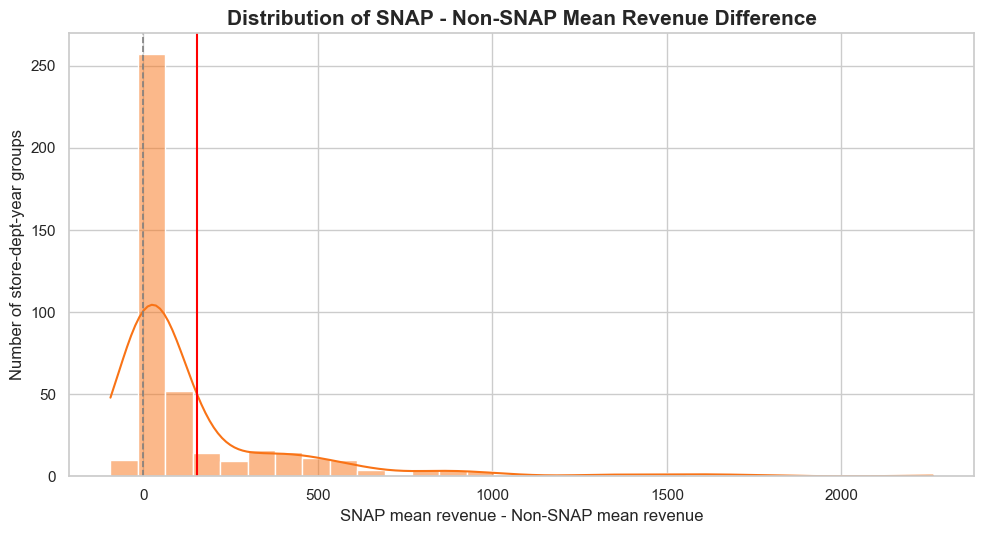

In [47]:
plt.figure(figsize=(10, 5.5))

ax = sns.histplot(
    snap_pivot["diff"],
    bins=30,
    kde=True,
    color="#F97316",
    edgecolor="white"
)

ax.axvline(0, color="gray", linestyle="--", linewidth=1.2)
ax.axvline(snap_pivot["diff"].mean(), color="red", linestyle="-", linewidth=1.5)

ax.set_title(
    "Distribution of SNAP - Non-SNAP Mean Revenue Difference",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("SNAP mean revenue - Non-SNAP mean revenue")
ax.set_ylabel("Number of store-dept-year groups")

plt.tight_layout()
plt.show()

**Kết luận kiểm định**

- Kết quả kiểm định cho thấy doanh thu trung bình trong các ngày `SNAP active` cao hơn so với các ngày `Non-SNAP`. Cụ thể, doanh thu trung bình Non-SNAP là **1,401.62**, trong khi doanh thu trung bình SNAP active là **1,555.80**. Chênh lệch trung bình đạt **154.18**, tương ứng mức tăng khoảng **8.21%**.

- Vì `paired_t_pvalue = 0.0000 < 0.05`, ta **bác bỏ giả thuyết H0** và có đủ bằng chứng để **ủng hộ giả thuyết H1**: doanh thu trong ngày SNAP active cao hơn doanh thu trong ngày Non-SNAP sau khi so sánh theo từng nhóm `store_id × dept_id × year`.

- Ngoài ra, `cohen_dz = 0.5112` cho thấy SNAP effect có mức ảnh hưởng trung bình. Vì vậy, `snap_active` được xem là feature candidate có cơ sở, nhưng tác động yếu hơn weekend effect và cần được kiểm chứng thêm trong giai đoạn modeling.

# 11. Kiểm định Mối Quan Hệ Giữa Doanh Thu Hiện Tại và Doanh Thu Quá Khứ

Kiểm định được thực hiện nhằm xác nhận liệu doanh thu hiện tại có mối liên hệ với doanh thu quá khứ của cùng chuỗi store_id × dept_id hay không. Trong bài toán dự báo doanh thu theo thời gian, các giá trị doanh thu ở những ngày trước đó thường chứa nhiều thông tin quan trọng về xu hướng, chu kỳ và hành vi mua hàng lặp lại.

Các lag được xem xét bao gồm các độ trễ ngắn hạn và theo chu kỳ như lag_1, lag_7, lag_14 và lag_28. Trong đó, lag_7 phản ánh chu kỳ theo tuần, còn lag_28 phản ánh xu hướng gần theo tháng.

Giả thuyết kiểm định:

- **H0**: Doanh thu hiện tại không có mối liên hệ đáng kể với doanh thu quá khứ của cùng chuỗi store_id × dept_id.

- **H1**: Doanh thu hiện tại có mối liên hệ đáng kể với doanh thu quá khứ của cùng chuỗi store_id × dept_id.

Kết quả kiểm định được sử dụng để đánh giá liệu các biến sales history như revenue_lag_1, revenue_lag_7, revenue_lag_14, revenue_lag_28 và các rolling features có đủ cơ sở để trở thành nhóm feature quan trọng trong mô hình dự báo hay không.

In [48]:
# =========================
# Lag Strength Test - Prepare Lag Features
# =========================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df_lag = df.copy()
df_lag["date"] = pd.to_datetime(df_lag["date"])

# Sắp xếp đúng thứ tự thời gian trong từng chuỗi store-dept
df_lag = df_lag.sort_values(["store_id", "dept_id", "date"]).reset_index(drop=True)

# Các lag cần kiểm tra
lag_days = [1, 7, 14, 28]

for lag in lag_days:
    df_lag[f"revenue_lag_{lag}"] = (
        df_lag
        .groupby(["store_id", "dept_id"])["daily_revenue"]
        .shift(lag)
    )

display(df_lag[["store_id", "dept_id", "date", "daily_revenue"] + [f"revenue_lag_{l}" for l in lag_days]].head(35))

,store_id,dept_id,date,daily_revenue,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_28
0,CA_1,FOODS_1,2011-01-29,681.1800,NaN,NaN,NaN,NaN
1,CA_1,FOODS_1,2011-01-30,643.6900,681.1800,NaN,NaN,NaN
2,CA_1,FOODS_1,2011-01-31,451.1400,643.6900,NaN,NaN,NaN
3,CA_1,FOODS_1,2011-02-01,400.3900,451.1400,NaN,NaN,NaN
4,CA_1,FOODS_1,2011-02-02,396.3600,400.3900,NaN,NaN,NaN
5,CA_1,FOODS_1,2011-02-03,434.4000,396.3600,NaN,NaN,NaN
6,CA_1,FOODS_1,2011-02-04,575.8100,434.4000,NaN,NaN,NaN
7,CA_1,FOODS_1,2011-02-05,586.1500,575.8100,681.1800,NaN,NaN
8,CA_1,FOODS_1,2011-02-06,595.4700,586.1500,643.6900,NaN,NaN
9,CA_1,FOODS_1,2011-02-07,405.6300,595.4700,451.1400,NaN,NaN


In [49]:
# =========================
# Lag Strength Test
# =========================

lag_corr_results = []

for lag in lag_days:
    lag_col = f"revenue_lag_{lag}"
    
    for (store_id, dept_id), group in df_lag.groupby(["store_id", "dept_id"]):
        tmp = group[["daily_revenue", lag_col]].dropna()
        
        if len(tmp) > 10:
            spearman_corr, spearman_p = stats.spearmanr(
                tmp["daily_revenue"],
                tmp[lag_col]
            )
            
            pearson_corr, pearson_p = stats.pearsonr(
                tmp["daily_revenue"],
                tmp[lag_col]
            )
            
            lag_corr_results.append({
                "store_id": store_id,
                "dept_id": dept_id,
                "lag": lag,
                "n_obs": len(tmp),
                "spearman_corr": spearman_corr,
                "spearman_pvalue": spearman_p,
                "pearson_corr": pearson_corr,
                "pearson_pvalue": pearson_p
            })

lag_corr_df = pd.DataFrame(lag_corr_results)

display(lag_corr_df.head())

,store_id,dept_id,lag,n_obs,spearman_corr,spearman_pvalue,pearson_corr,pearson_pvalue
0,CA_1,FOODS_1,1,1940,0.7037,0.0000,0.6678,0.0000
1,CA_1,FOODS_2,1,1940,0.6560,0.0000,0.6403,0.0000
2,CA_1,FOODS_3,1,1940,0.6732,0.0000,0.6295,0.0000
3,CA_1,HOBBIES_1,1,1940,0.7967,0.0000,0.7605,0.0000
4,CA_1,HOBBIES_2,1,1940,0.5730,0.0000,0.5817,0.0000


In [50]:
# =========================
# Summary Lag Strength
# =========================

summary_results = []

for lag in lag_days:
    tmp = lag_corr_df[lag_corr_df["lag"] == lag].copy()
    
    # Kiểm định: median Spearman correlation > 0
    # H0: median correlation <= 0
    # H1: median correlation > 0
    try:
        wilcoxon_stat, wilcoxon_pvalue = stats.wilcoxon(
            tmp["spearman_corr"],
            alternative="greater"
        )
    except ValueError:
        wilcoxon_stat, wilcoxon_pvalue = np.nan, np.nan
    
    summary_results.append({
        "lag": lag,
        "n_series": tmp.shape[0],
        "mean_spearman_corr": tmp["spearman_corr"].mean(),
        "median_spearman_corr": tmp["spearman_corr"].median(),
        "min_spearman_corr": tmp["spearman_corr"].min(),
        "max_spearman_corr": tmp["spearman_corr"].max(),
        "wilcoxon_pvalue": wilcoxon_pvalue
    })

lag_strength_summary = pd.DataFrame(summary_results)

lag_strength_summary = lag_strength_summary.round({
    "mean_spearman_corr": 4,
    "median_spearman_corr": 4,
    "min_spearman_corr": 4,
    "max_spearman_corr": 4,
    "wilcoxon_pvalue": 6
})

display(lag_strength_summary)

,lag,n_series,mean_spearman_corr,median_spearman_corr,min_spearman_corr,max_spearman_corr,wilcoxon_pvalue
0,1,70,0.6555,0.6562,0.3302,0.8926,0.0000
1,7,70,0.6756,0.6975,0.3143,0.9092,0.0000
2,14,70,0.6197,0.6646,-0.0832,0.9077,0.0000
3,28,70,0.6742,0.6946,0.2275,0.8981,0.0000


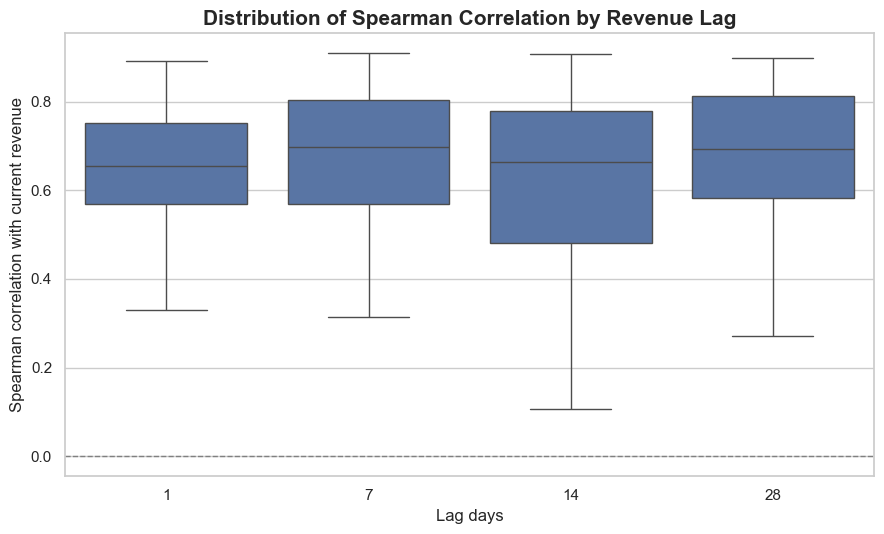

In [51]:
# =========================
# Visualization: Lag Strength
# =========================

sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(9, 5.5))

ax = sns.boxplot(
    data=lag_corr_df,
    x="lag",
    y="spearman_corr",
    showfliers=False
)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)

ax.set_title(
    "Distribution of Spearman Correlation by Revenue Lag",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Lag days")
ax.set_ylabel("Spearman correlation with current revenue")

plt.tight_layout()
plt.show()

In [52]:
# =========================
# Revenue Autocorrelation by Department
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

df_auto = df.copy()
df_auto["date"] = pd.to_datetime(df_auto["date"])

# Sắp xếp đúng thứ tự thời gian trong từng chuỗi store-dept
df_auto = df_auto.sort_values(["store_id", "dept_id", "date"]).reset_index(drop=True)

# Các lag muốn kiểm tra
lags = [1, 7, 14, 28, 56]

# Tạo lag theo từng store_id × dept_id
for lag in lags:
    df_auto[f"revenue_lag_{lag}"] = (
        df_auto
        .groupby(["store_id", "dept_id"])["daily_revenue"]
        .shift(lag)
    )

# Tính correlation giữa doanh thu hiện tại và lag theo từng department
dept_corr_results = []

for dept_id, group in df_auto.groupby("dept_id"):
    row = {"dept_id": dept_id}
    
    for lag in lags:
        lag_col = f"revenue_lag_{lag}"
        tmp = group[["daily_revenue", lag_col]].dropna()
        
        # Spearman để đồng nhất với kiểm định Lag Strength trước đó
        corr = tmp["daily_revenue"].corr(tmp[lag_col], method="spearman")
        
        row[f"corr_lag_{lag}"] = corr
    
    dept_corr_results.append(row)

dept_corr_df = pd.DataFrame(dept_corr_results)

# Sắp xếp department theo lag_7 để biểu đồ dễ đọc
dept_corr_df = dept_corr_df.sort_values("corr_lag_7", ascending=False)

display(dept_corr_df.round(4))

,dept_id,corr_lag_1,corr_lag_7,corr_lag_14,corr_lag_28,corr_lag_56
5,HOUSEHOLD_1,0.8439,0.9010,0.8994,0.8986,0.8744
6,HOUSEHOLD_2,0.8367,0.8753,0.8753,0.8657,0.8388
3,HOBBIES_1,0.8292,0.8715,0.8721,0.8685,0.8521
2,FOODS_3,0.8497,0.8635,0.8065,0.8865,0.8384
1,FOODS_2,0.8707,0.8019,0.7013,0.8685,0.8054
0,FOODS_1,0.8278,0.7959,0.7672,0.7781,0.7685
4,HOBBIES_2,0.6210,0.5996,0.5711,0.5401,0.5275


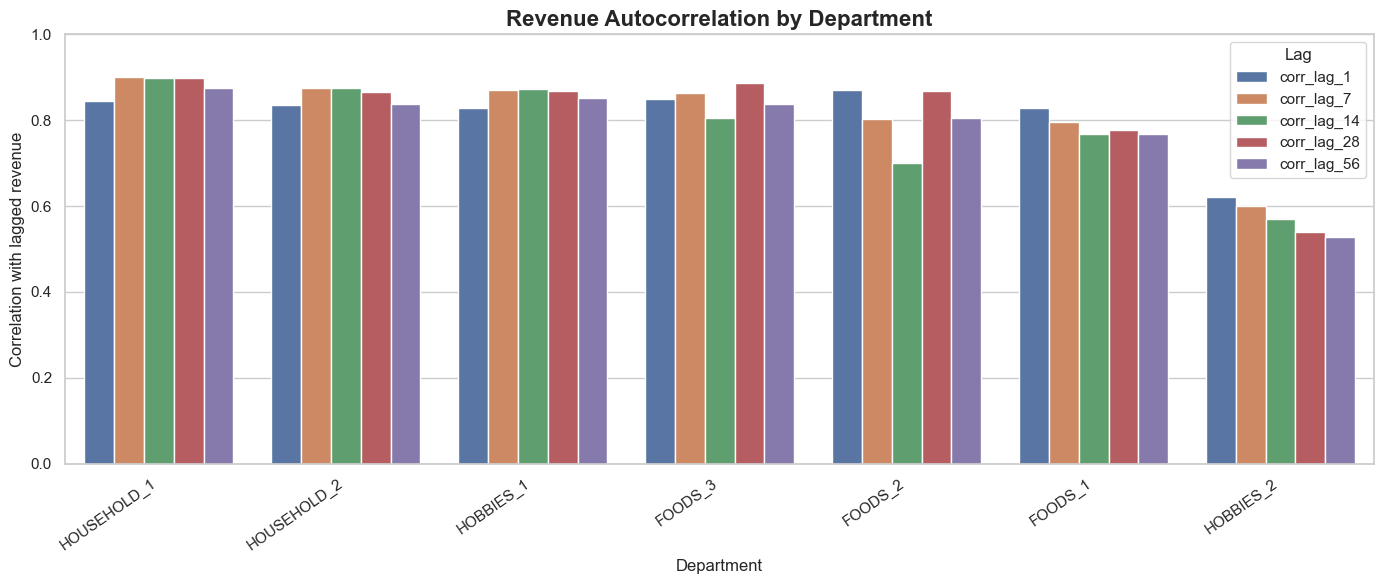

In [53]:
# =========================
# Plot
# =========================

dept_corr_long = dept_corr_df.melt(
    id_vars="dept_id",
    value_vars=[f"corr_lag_{lag}" for lag in lags],
    var_name="Lag",
    value_name="Correlation"
)

# Đổi tên legend cho đẹp
dept_corr_long["Lag"] = dept_corr_long["Lag"].str.replace("corr_", "corr_", regex=False)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=dept_corr_long,
    x="dept_id",
    y="Correlation",
    hue="Lag"
)

ax.set_title(
    "Revenue Autocorrelation by Department",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Department")
ax.set_ylabel("Correlation with lagged revenue")

plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)

plt.legend(title="Lag", loc="upper right")
plt.tight_layout()
plt.show()

**Kết quả kiểm định**

- Kết quả kiểm định cho thấy các biến lag đều có mối tương quan dương rõ rệt với doanh thu hiện tại. Cụ thể, median Spearman correlation của các lag 1, 7, 14 và 28 đều nằm quanh mức 0.65–0.70, cho thấy doanh thu hiện tại có liên hệ khá mạnh với doanh thu trong quá khứ của cùng chuỗi store_id × dept_id.

- Trong đó, lag_7 và lag_28 có mức tương quan cao hơn, phản ánh tính chu kỳ theo tuần và gần theo tháng trong hành vi mua hàng. Đồng thời, p-value từ Wilcoxon signed-rank test đều nhỏ hơn 0.05, nên có cơ sở bác bỏ H0 và kết luận rằng các lag doanh thu có mối liên hệ đáng kể với doanh thu hiện tại.

- Biểu đồ phân phối correlation cũng cho thấy phần lớn các chuỗi có tương quan dương cao hơn nhiều so với mốc 0. Vì vậy, nhóm sales history features như revenue_lag_1, revenue_lag_7, revenue_lag_14, revenue_lag_28 và các rolling features là nhóm feature quan trọng cần được đưa vào giai đoạn modeling.

# 12. Kiểm định Weather Effect

Kiểm định được thực hiện nhằm xác nhận liệu doanh thu tương đối (`revenue_index`) có khác nhau giữa các nhóm thời tiết hay không. Do weather được chia thành nhiều nhóm như `temp_bin`, `rain_level` và `wind_bin`, ta sử dụng **Kruskal-Wallis test** thay vì paired t-test.

Giả thuyết kiểm định:

**H0:** Phân phối `revenue_index` không khác nhau giữa các nhóm thời tiết.

**H1:** Có ít nhất một nhóm thời tiết có phân phối `revenue_index` khác biệt.

Do dữ liệu có số lượng quan sát lớn, p-value rất dễ nhỏ. Vì vậy, ngoài p-value, ta sử dụng thêm **epsilon squared** để đánh giá mức độ ảnh hưởng thực tế của weather.

In [54]:
from scipy.stats import kruskal
import pandas as pd
import numpy as np

# =========================
# 1. Chuẩn bị dữ liệu weather
# =========================

df_weather = df.copy()
df_weather["date"] = pd.to_datetime(df_weather["date"])

# Revenue index để chuẩn hóa theo từng chuỗi store-department
df_weather["series_mean_revenue"] = (
    df_weather
    .groupby(["store_id", "dept_id"])["daily_revenue"]
    .transform("mean")
)

df_weather["revenue_index"] = (
    df_weather["daily_revenue"] / df_weather["series_mean_revenue"]
)

# Temperature bin
df_weather["temp_bin"] = pd.cut(
    df_weather["temperature_mean_c"],
    bins=[-np.inf, 0, 10, 20, 30, np.inf],
    labels=["Very cold", "Cold", "Mild", "Warm", "Hot"]
)

# Rain bin
df_weather["rain_level"] = pd.cut(
    df_weather["precipitation_mm"],
    bins=[-0.01, 0, 2.5, 10, np.inf],
    labels=["No rain", "Light rain", "Moderate rain", "Heavy rain"]
)

# Wind bin
df_weather["wind_bin"] = pd.cut(
    df_weather["wind_speed_max_kmh"],
    bins=[-np.inf, 15, 30, 45, np.inf],
    labels=["Low wind", "Moderate wind", "Strong wind", "Very strong wind"]
)

In [55]:
# =========================
# 2. Hàm kiểm định Kruskal-Wallis + effect size
# =========================

def kruskal_weather_test(data, group_col, value_col="revenue_index"):
    tmp = data[[group_col, value_col]].dropna().copy()
    
    groups = [
        group[value_col].values
        for _, group in tmp.groupby(group_col, observed=True)
        if len(group) > 0
    ]
    
    h_stat, p_value = kruskal(*groups)
    
    n = len(tmp)
    k = tmp[group_col].nunique()
    
    # Epsilon squared effect size
    epsilon_squared = max(0, (h_stat - k + 1) / (n - k))
    
    summary = (
        tmp.groupby(group_col, observed=True)
        .agg(
            n=(value_col, "size"),
            mean_revenue_index=(value_col, "mean"),
            median_revenue_index=(value_col, "median")
        )
        .reset_index()
    )
    
    result = {
        "weather_group": group_col,
        "n": n,
        "n_groups": k,
        "h_stat": h_stat,
        "p_value": p_value,
        "epsilon_squared": epsilon_squared
    }
    
    return result, summary

In [56]:
# =========================
# 3. Chạy kiểm định cho temp, rain, wind
# =========================

weather_test_results = []
weather_group_summaries = {}

for col in ["temp_bin", "rain_level", "wind_bin"]:
    result, summary = kruskal_weather_test(
        df_weather,
        group_col=col,
        value_col="revenue_index"
    )
    
    weather_test_results.append(result)
    weather_group_summaries[col] = summary

weather_test_result = pd.DataFrame(weather_test_results)

# Làm tròn để bảng dễ đọc
weather_test_result["h_stat"] = weather_test_result["h_stat"].round(4)
weather_test_result["p_value"] = weather_test_result["p_value"].apply(lambda x: f"{x:.4e}")
weather_test_result["epsilon_squared"] = weather_test_result["epsilon_squared"].round(6)

display(weather_test_result)

,weather_group,n,n_groups,h_stat,p_value,epsilon_squared
0,temp_bin,135870,5,213.2505,5.3106e-45,0.0015
1,rain_level,135870,4,33.0386,3.1608e-07,0.0002
2,wind_bin,135870,4,133.2249,1.0916e-28,0.0010


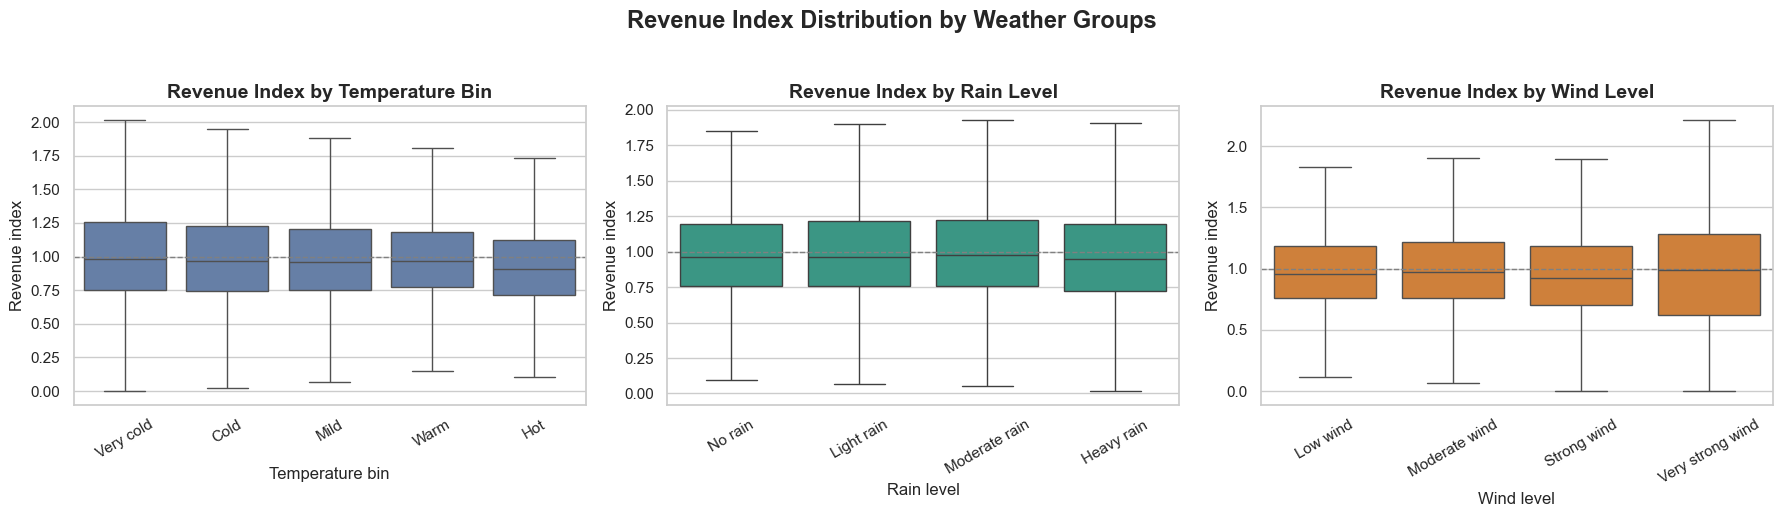

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# 1. Temperature bin
# =========================
sns.boxplot(
    data=df_weather,
    x="temp_bin",
    y="revenue_index",
    showfliers=False,
    color="#5B7DB1",
    ax=axes[0]
)

axes[0].axhline(1, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Revenue Index by Temperature Bin", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Temperature bin")
axes[0].set_ylabel("Revenue index")
axes[0].tick_params(axis="x", rotation=30)

# =========================
# 2. Rain level
# =========================
sns.boxplot(
    data=df_weather,
    x="rain_level",
    y="revenue_index",
    showfliers=False,
    color="#2CA58D",
    ax=axes[1]
)

axes[1].axhline(1, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Revenue Index by Rain Level", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Rain level")
axes[1].set_ylabel("Revenue index")
axes[1].tick_params(axis="x", rotation=30)

# =========================
# 3. Wind bin
# =========================
sns.boxplot(
    data=df_weather,
    x="wind_bin",
    y="revenue_index",
    showfliers=False,
    color="#E67E22",
    ax=axes[2]
)

axes[2].axhline(1, color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Revenue Index by Wind Level", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Wind level")
axes[2].set_ylabel("Revenue index")
axes[2].tick_params(axis="x", rotation=30)

fig.suptitle(
    "Revenue Index Distribution by Weather Groups",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

**Kết luận kiểm định**

- Kết quả Kruskal-Wallis test cho thấy revenue_index có sự khác biệt có ý nghĩa thống kê giữa các nhóm thời tiết như temp_bin, rain_level và wind_bin, với p-value đều nhỏ hơn 0.05. Do đó, ta bác bỏ H0 và có cơ sở cho rằng điều kiện thời tiết có liên quan đến sự thay đổi doanh thu tương đối.

- Tuy nhiên, giá trị epsilon_squared của cả ba nhóm đều rất nhỏ, lần lượt khoảng 0.0015 đối với nhiệt độ, 0.0002 đối với mưa và 0.0010 đối với gió. Điều này cho thấy mặc dù khác biệt có ý nghĩa thống kê, mức ảnh hưởng thực tế của weather lên doanh thu là rất yếu.

- Biểu đồ boxplot cũng củng cố nhận định này: phân phối revenue_index giữa các nhóm thời tiết chồng lấn nhiều và median hầu hết nằm quanh mức 1.0. Vì vậy, weather có thể được xem là nhóm feature phụ, nhưng không phải yếu tố chính quyết định doanh thu. Các biến weather cần được kiểm chứng thêm bằng model ablation trước khi quyết định giữ trong feature set cuối cùng.

# 13. Feature Engineering


In [58]:
def prepare_model_frame(source_df):
    out = source_df.copy()

    # Clean event columns.
    for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]:
        out[col] = out[col].fillna("No Event").astype(str)

    # Calendar cyclic features.
    out["date_index"] = (out["date"] - out["date"].min()).dt.days + 1
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week_num"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week_num"] / 7)
    out["doy_sin"] = np.sin(2 * np.pi * out["day_of_year"] / 366)
    out["doy_cos"] = np.cos(2 * np.pi * out["day_of_year"] / 366)
    out["week_sin"] = np.sin(2 * np.pi * out["week_of_year"] / 53)
    out["week_cos"] = np.cos(2 * np.pi * out["week_of_year"] / 53)

    # Weather flags for with-weather model.
    out["is_rainy_day"] = (out["precipitation_mm"] > 0).astype(int)
    out["is_heavy_rain_day"] = (out["precipitation_mm"] >= 10).astype(int)
    out["is_snowy_day"] = (out["snowfall_cm"] > 0).astype(int)
    out["is_hot_day"] = (out["temperature_mean_c"] >= 30).astype(int)
    out["is_cold_day"] = (out["temperature_mean_c"] <= 0).astype(int)

    # History features. Everything is shifted before rolling to avoid same-day leakage.
    out = out.sort_values(["store_id", "dept_id", "date"]).reset_index(drop=True)
    group = out.groupby(["store_id", "dept_id"], sort=False)

    for lag in [1, 7, 14, 28, 56]:
        out[f"revenue_lag_{lag}"] = group["daily_revenue"].shift(lag)

    shifted = group["daily_revenue"].shift(1)
    for window in [7, 14, 28, 56]:
        out[f"revenue_roll_mean_{window}"] = (
            shifted.groupby([out["store_id"], out["dept_id"]])
            .rolling(window, min_periods=1)
            .mean()
            .reset_index(level=[0, 1], drop=True)
        )

    for window in [7, 28]:
        out[f"revenue_roll_std_{window}"] = (
            shifted.groupby([out["store_id"], out["dept_id"]])
            .rolling(window, min_periods=2)
            .std()
            .reset_index(level=[0, 1], drop=True)
        )

    out["revenue_expanding_mean"] = group["daily_revenue"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    out["zero_sales_roll_28"] = (
        group["has_sales"].shift(1).rsub(1)
        .groupby([out["store_id"], out["dept_id"]])
        .rolling(28, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    return out


df_model = prepare_model_frame(df)

history_features = [
    "revenue_lag_1", "revenue_lag_7", "revenue_lag_14", "revenue_lag_28", "revenue_lag_56",
    "revenue_roll_mean_7", "revenue_roll_mean_14", "revenue_roll_mean_28", "revenue_roll_mean_56",
    "revenue_roll_std_7", "revenue_roll_std_28", "revenue_expanding_mean", "zero_sales_roll_28",
]

print("Model frame shape:", df_model.shape)
print("History feature missing counts:")
display(df_model[history_features].isna().sum().to_frame("missing_count"))

display(df_model[key_cols + ["daily_revenue"] + history_features[:8]].head(12))


Model frame shape: (135870, 88)
History feature missing counts:


,missing_count
revenue_lag_1,70
revenue_lag_7,490
revenue_lag_14,980
revenue_lag_28,1960
revenue_lag_56,3920
revenue_roll_mean_7,70
revenue_roll_mean_14,70
revenue_roll_mean_28,70
revenue_roll_mean_56,70
revenue_roll_std_7,140


,date,store_id,dept_id,daily_revenue,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_28,revenue_lag_56,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_28
0,2011-01-29,CA_1,FOODS_1,681.1800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-30,CA_1,FOODS_1,643.6900,681.1800,NaN,NaN,NaN,NaN,681.1800,681.1800,681.1800
2,2011-01-31,CA_1,FOODS_1,451.1400,643.6900,NaN,NaN,NaN,NaN,662.4350,662.4350,662.4350
3,2011-02-01,CA_1,FOODS_1,400.3900,451.1400,NaN,NaN,NaN,NaN,592.0033,592.0033,592.0033
4,2011-02-02,CA_1,FOODS_1,396.3600,400.3900,NaN,NaN,NaN,NaN,544.1000,544.1000,544.1000
5,2011-02-03,CA_1,FOODS_1,434.4000,396.3600,NaN,NaN,NaN,NaN,514.5520,514.5520,514.5520
6,2011-02-04,CA_1,FOODS_1,575.8100,434.4000,NaN,NaN,NaN,NaN,501.1933,501.1933,501.1933
7,2011-02-05,CA_1,FOODS_1,586.1500,575.8100,681.1800,NaN,NaN,NaN,511.8529,511.8529,511.8529
8,2011-02-06,CA_1,FOODS_1,595.4700,586.1500,643.6900,NaN,NaN,NaN,498.2771,521.1400,521.1400
9,2011-02-07,CA_1,FOODS_1,405.6300,595.4700,451.1400,NaN,NaN,NaN,491.3886,529.3989,529.3989


# 14. Time-Based Split


In [59]:
train_df = df_model[df_model["year"] <= 2014].copy()
val_df = df_model[df_model["year"] == 2015].copy()
test_df = df_model[df_model["year"] == 2016].copy()
train_val_df = df_model[df_model["year"] <= 2015].copy()

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test", "train_plus_validation"],
    "date_min": [train_df.date.min(), val_df.date.min(), test_df.date.min(), train_val_df.date.min()],
    "date_max": [train_df.date.max(), val_df.date.max(), test_df.date.max(), train_val_df.date.max()],
    "rows": [len(train_df), len(val_df), len(test_df), len(train_val_df)],
    "unique_dates": [train_df.date.nunique(), val_df.date.nunique(), test_df.date.nunique(), train_val_df.date.nunique()],
})
display(split_summary)


,split,date_min,date_max,rows,unique_dates
0,train,2011-01-29,2014-12-31,100310,1433
1,validation,2015-01-01,2015-12-31,25550,365
2,test,2016-01-01,2016-05-22,10010,143
3,train_plus_validation,2011-01-29,2015-12-31,125860,1798


# 15. LightGBM Model


In [60]:
def fit_mean_baselines(train):
    return {
        "global_mean": train["daily_revenue"].mean(),
        "dept_mean": train.groupby("dept_id")["daily_revenue"].mean(),
        "store_mean": train.groupby("store_id")["daily_revenue"].mean(),
        "store_dept_mean": train.groupby(["store_id", "dept_id"])["daily_revenue"].mean(),
    }


def map_group_mean(data, series, keys, fallback):
    idx = data.set_index(keys).index
    return pd.Series(idx.map(series), index=data.index).fillna(fallback).astype(float).values


def predict_mean_baseline(model, data, kind):
    if kind == "global_mean":
        return np.full(len(data), model["global_mean"])
    if kind == "dept_mean":
        return data["dept_id"].map(model["dept_mean"]).fillna(model["global_mean"]).values
    if kind == "store_mean":
        return data["store_id"].map(model["store_mean"]).fillna(model["global_mean"]).values
    if kind == "store_dept_mean":
        return map_group_mean(data, model["store_dept_mean"], ["store_id", "dept_id"], model["global_mean"])
    raise ValueError(kind)


def predict_history_baseline(train, data, history_col):
    model = fit_mean_baselines(train)
    fallback = map_group_mean(data, model["store_dept_mean"], ["store_id", "dept_id"], model["global_mean"])
    return data[history_col].fillna(pd.Series(fallback, index=data.index)).values

baseline_model = fit_mean_baselines(train_df)

baseline_rows = []
for name in ["global_mean", "dept_mean", "store_mean", "store_dept_mean"]:
    pred = predict_mean_baseline(baseline_model, val_df, name)
    baseline_rows.append({"model": name, **evaluate_regression(val_df["daily_revenue"], pred)})

for col in ["revenue_lag_1", "revenue_lag_7", "revenue_lag_28", "revenue_roll_mean_7", "revenue_roll_mean_28"]:
    pred = predict_history_baseline(train_df, val_df, col)
    baseline_rows.append({"model": col, **evaluate_regression(val_df["daily_revenue"], pred)})

val_baseline_results = display_metrics_table(baseline_rows)


,model,MAE,RMSE,WAPE,R2,Bias
6,revenue_lag_28,249.0650,411.6640,0.1500,0.9215,-16.2910
5,revenue_lag_7,266.5270,456.4310,0.1605,0.9034,-3.4430
7,revenue_roll_mean_7,290.7040,474.2310,0.1751,0.8958,-2.3780
8,revenue_roll_mean_28,296.9580,484.0100,0.1789,0.8914,-8.1630
4,revenue_lag_1,300.3080,511.0270,0.1809,0.8790,-1.1890
3,store_dept_mean,456.4280,723.5630,0.2749,0.7573,-360.9050
1,dept_mean,550.4410,919.8100,0.3316,0.6079,-360.9050
2,store_mean,"1,048.2760","1,456.2220",0.6314,0.0171,-360.9050
0,global_mean,"1,069.3610","1,512.5400",0.6441,-0.0604,-360.9050


In [61]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

from lightgbm import LGBMRegressor

LIGHTGBM_PARAMS = {
    "objective": "regression_l1",
    "n_estimators": 700,
    "learning_rate": 0.04,
    "num_leaves": 64,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

print("Model used: LGBMRegressor with weather features only")
print("LightGBM params:")
for key, value in LIGHTGBM_PARAMS.items():
    print(f"- {key}: {value}")

# Explicit store-dept interaction. This is known before forecasting and is not leakage.
for frame in [df_model, train_df, val_df, test_df, train_val_df]:
    frame["store_dept_id"] = frame["store_id"].astype(str) + "__" + frame["dept_id"].astype(str)

numeric_base_features = [
    "item_count", "snap_active", "event_count", "date_index", "year",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos", "week_sin", "week_cos", "is_weekend",
]

numeric_history_features = history_features.copy()

numeric_weather_features = [
    "temperature_max_c", "temperature_min_c", "temperature_mean_c", "apparent_temperature_mean_c",
    "precipitation_mm", "rain_mm", "snowfall_cm", "wind_speed_max_kmh", "wind_gusts_max_kmh",
    "shortwave_radiation_mj_m2", "is_rainy_day", "is_heavy_rain_day", "is_snowy_day", "is_hot_day", "is_cold_day",
]

categorical_features = [
    "store_id", "state_id", "cat_id", "dept_id", "store_dept_id",
    "month", "day_of_week_num", "event_name_1", "event_type_1", "event_name_2", "event_type_2", "weather_code",
]


def keep_existing(cols, data=df_model):
    return [col for col in cols if col in data.columns]

numeric_features = keep_existing(numeric_base_features + numeric_history_features + numeric_weather_features)
categorical_features = keep_existing(categorical_features)
feature_cols = numeric_features + categorical_features

print("\nFinal feature set: with_weather")
print("Numeric features:", len(numeric_features), numeric_features)
print("Categorical features:", len(categorical_features), categorical_features)
print("Total raw feature columns:", len(feature_cols))


Model used: LGBMRegressor with weather features only
LightGBM params:
- objective: regression_l1
- n_estimators: 700
- learning_rate: 0.04
- num_leaves: 64
- max_depth: -1
- min_child_samples: 50
- subsample: 0.85
- colsample_bytree: 0.85
- reg_alpha: 0.1
- reg_lambda: 1.0
- random_state: 42
- n_jobs: -1
- verbosity: -1

Final feature set: with_weather
Numeric features: 42 ['item_count', 'snap_active', 'event_count', 'date_index', 'year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'week_sin', 'week_cos', 'is_weekend', 'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_14', 'revenue_lag_28', 'revenue_lag_56', 'revenue_roll_mean_7', 'revenue_roll_mean_14', 'revenue_roll_mean_28', 'revenue_roll_mean_56', 'revenue_roll_std_7', 'revenue_roll_std_28', 'revenue_expanding_mean', 'zero_sales_roll_28', 'temperature_max_c', 'temperature_min_c', 'temperature_mean_c', 'apparent_temperature_mean_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm', 'wind_speed_max_kmh', 'wind_gust

In [62]:
def build_lightgbm_with_weather_pipeline():
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]), numeric_features),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                )),
            ]), categorical_features),
        ]
    )

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMRegressor(**LIGHTGBM_PARAMS)),
    ])


def fit_predict_lightgbm_with_weather(train, pred, target_col="daily_revenue"):
    model = build_lightgbm_with_weather_pipeline()
    model.fit(train[feature_cols], train[target_col])
    pred_values = np.clip(model.predict(pred[feature_cols]), 0, None)
    return model, pred_values


def evaluate_predictions(y_true, y_pred):
    return evaluate_regression(y_true, y_pred)


def result_row(split_name, train, eval_df, pred_values):
    return {
        "split": split_name,
        "model": "lightgbm_with_weather",
        "n_train": len(train),
        "n_eval": len(eval_df),
        "n_numeric": len(numeric_features),
        "n_categorical": len(categorical_features),
        **evaluate_predictions(eval_df["daily_revenue"], pred_values),
    }


# 16. Validation

In [63]:
print("Training LightGBM with weather on train 2011-2014...")
val_model, val_pred = fit_predict_lightgbm_with_weather(
    train=train_df,
    pred=val_df,
    target_col="daily_revenue",
)

val_model_results = pd.DataFrame([
    result_row("validation_2015", train_df, val_df, val_pred)
])

display(val_model_results.round({"MAE": 3, "RMSE": 3, "WAPE": 4, "R2": 4, "Bias": 3}))


Training LightGBM with weather on train 2011-2014...


,split,model,n_train,n_eval,n_numeric,n_categorical,MAE,RMSE,WAPE,R2,Bias
0,validation_2015,lightgbm_with_weather,100310,25550,42,12,159.7350,261.2470,0.0962,0.9684,-46.5730


# 17. Test

In [64]:
print("Training LightGBM with weather on train+validation 2011-2015...")
final_lightgbm_model, test_pred_values = fit_predict_lightgbm_with_weather(
    train=train_val_df,
    pred=test_df,
    target_col="daily_revenue",
)

final_model_results = pd.DataFrame([
    result_row("test_2016", train_val_df, test_df, test_pred_values)
])

display(final_model_results.round({"MAE": 3, "RMSE": 3, "WAPE": 4, "R2": 4, "Bias": 3}))

primary_model_name = "lightgbm_with_weather"
primary_model = final_lightgbm_model
primary_pred = test_pred_values
primary_result = final_model_results.iloc[0]

print("Primary model:", primary_model_name)
print("Test MAE:", round(primary_result["MAE"], 3))
print("Test RMSE:", round(primary_result["RMSE"], 3))
print("Test WAPE:", round(primary_result["WAPE"], 4))
print("Test R2:", round(primary_result["R2"], 4))


Training LightGBM with weather on train+validation 2011-2015...


,split,model,n_train,n_eval,n_numeric,n_categorical,MAE,RMSE,WAPE,R2,Bias
0,test_2016,lightgbm_with_weather,125860,10010,42,12,169.1010,266.9340,0.0899,0.9733,-27.5610


Primary model: lightgbm_with_weather
Test MAE: 169.101
Test RMSE: 266.934
Test WAPE: 0.0899
Test R2: 0.9733


# 18. Error Analysis

,cat_id,dept_id,n,actual_revenue,predicted_revenue,mae,bias,mean_actual,wape
2,FOODS,FOODS_3,1430,"6,491,608.6400","6,306,988.4700",321.1600,-129.1100,"4,539.5900",0.0284
5,HOUSEHOLD,HOUSEHOLD_1,1430,"4,316,847.7500","4,264,341.5900",265.4200,-36.7200,"3,018.7700",0.0122
1,FOODS,FOODS_2,1430,"2,935,488.9700","2,916,590.2300",193.0400,-13.2200,"2,052.7900",0.0064
3,HOBBIES,HOBBIES_1,1430,"2,344,591.0100","2,345,423.9600",168.6800,0.5800,"1,639.5700",0.0004
0,FOODS,FOODS_1,1430,"1,277,373.4500","1,264,289.7500",113.9700,-9.1500,893.2700,0.0102
6,HOUSEHOLD,HOUSEHOLD_2,1430,"1,354,589.7400","1,347,812.1000",100.9600,-4.7400,947.2700,0.0050
4,HOBBIES,HOBBIES_2,1430,"114,766.4400","113,932.9100",20.4800,-0.5800,80.2600,0.0073


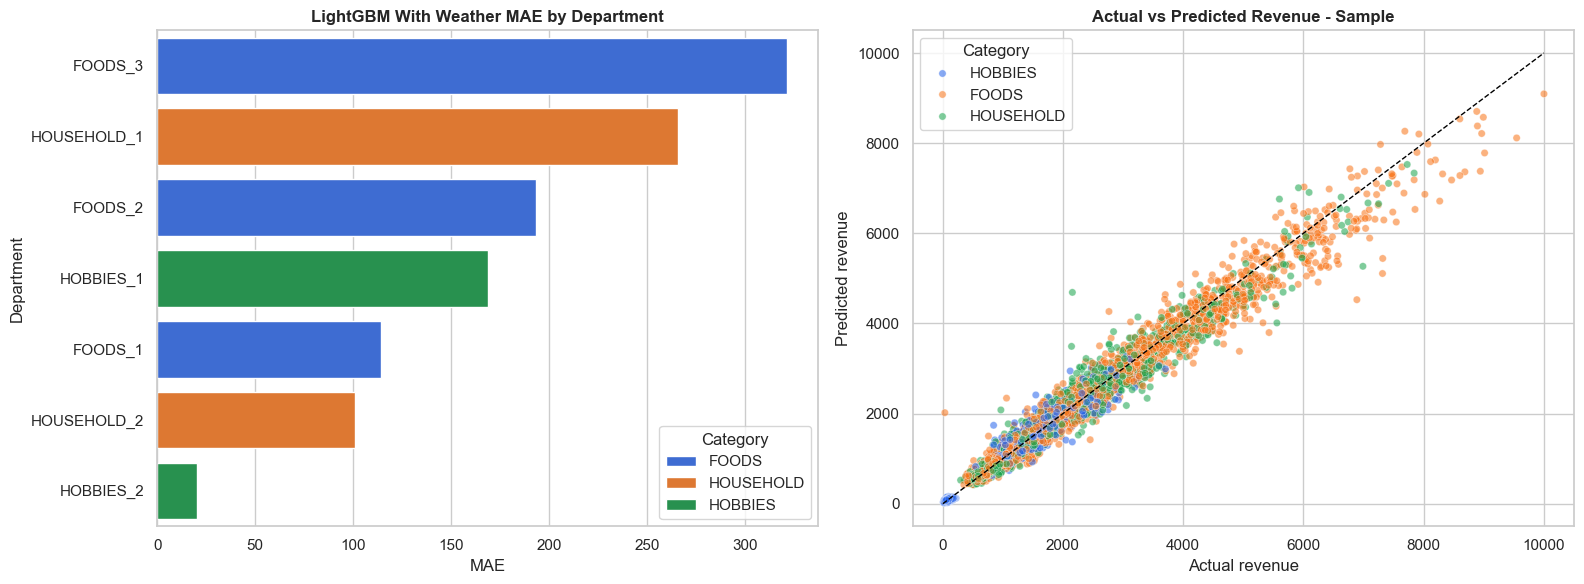

In [65]:
test_pred = test_df[["date", "store_id", "state_id", "cat_id", "dept_id", "store_dept_id", "daily_revenue"]].copy()
test_pred["pred_daily_revenue"] = primary_pred
test_pred["error"] = test_pred["pred_daily_revenue"] - test_pred["daily_revenue"]
test_pred["abs_error"] = test_pred["error"].abs()

error_by_dept = (
    test_pred.groupby(["cat_id", "dept_id"])
    .agg(
        n=("daily_revenue", "size"),
        actual_revenue=("daily_revenue", "sum"),
        predicted_revenue=("pred_daily_revenue", "sum"),
        mae=("abs_error", "mean"),
        bias=("error", "mean"),
        mean_actual=("daily_revenue", "mean"),
    )
    .reset_index()
)
error_by_dept["wape"] = (error_by_dept["predicted_revenue"] - error_by_dept["actual_revenue"]).abs() / (error_by_dept["actual_revenue"] + 1e-12)
error_by_dept = error_by_dept.sort_values("mae", ascending=False)

display(error_by_dept.round({"actual_revenue": 2, "predicted_revenue": 2, "mae": 2, "bias": 2, "mean_actual": 2, "wape": 4}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=error_by_dept, y="dept_id", x="mae", hue="cat_id", dodge=False, palette=PALETTE_CONTRAST, ax=axes[0])
axes[0].set_title("LightGBM With Weather MAE by Department")
axes[0].set_xlabel("MAE")
axes[0].set_ylabel("Department")
axes[0].legend(title="Category")

sample_plot = test_pred.sample(min(5000, len(test_pred)), random_state=42)
sns.scatterplot(data=sample_plot, x="daily_revenue", y="pred_daily_revenue", hue="cat_id", alpha=0.55, s=28, palette=PALETTE_CONTRAST, ax=axes[1])
max_val = max(sample_plot["daily_revenue"].max(), sample_plot["pred_daily_revenue"].max())
axes[1].plot([0, max_val], [0, max_val], color="black", linestyle="--", linewidth=1)
axes[1].set_title("Actual vs Predicted Revenue - Sample")
axes[1].set_xlabel("Actual revenue")
axes[1].set_ylabel("Predicted revenue")
axes[1].legend(title="Category")

plt.tight_layout()
plt.show()


,store_id,state_id,n,actual_revenue,predicted_revenue,mae,bias,wape
8,WI_2,WI,1001,"2,174,041.9000","2,088,548.7300",224.4600,-85.4100,0.0393
2,CA_3,CA,1001,"2,914,702.2200","2,862,154.7200",211.0800,-52.5000,0.0180
1,CA_2,CA,1001,"2,036,471.6700","2,014,184.2200",210.2100,-22.2700,0.0109
6,TX_3,TX,1001,"1,877,768.3000","1,849,186.9400",176.8300,-28.5500,0.0152
5,TX_2,TX,1001,"1,860,137.7600","1,844,730.7000",163.1700,-15.3900,0.0083
0,CA_1,CA,1001,"2,067,578.2600","2,050,776.3000",160.3800,-16.7900,0.0081
7,WI_1,WI,1001,"1,646,180.9300","1,641,418.3300",158.4700,-4.7600,0.0029
9,WI_3,WI,1001,"1,581,725.1700","1,557,821.9600",146.2600,-23.8800,0.0151
4,TX_1,TX,1001,"1,467,844.7000","1,457,810.0900",136.7100,-10.0200,0.0068
3,CA_4,CA,1001,"1,208,815.1000","1,192,747.0400",103.4500,-16.0500,0.0133


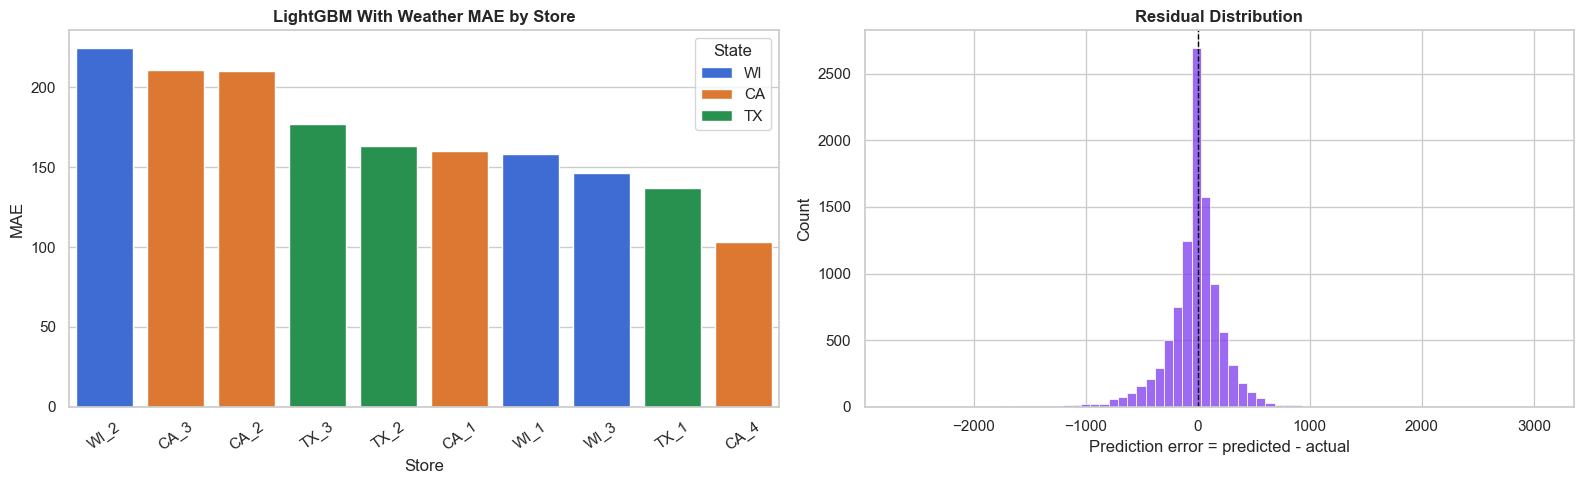

In [66]:
error_by_store = (
    test_pred.groupby(["store_id", "state_id"])
    .agg(
        n=("daily_revenue", "size"),
        actual_revenue=("daily_revenue", "sum"),
        predicted_revenue=("pred_daily_revenue", "sum"),
        mae=("abs_error", "mean"),
        bias=("error", "mean"),
    )
    .reset_index()
)
error_by_store["wape"] = (error_by_store["predicted_revenue"] - error_by_store["actual_revenue"]).abs() / (error_by_store["actual_revenue"] + 1e-12)
error_by_store = error_by_store.sort_values("mae", ascending=False)

display(error_by_store.round({"actual_revenue": 2, "predicted_revenue": 2, "mae": 2, "bias": 2, "wape": 4}))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=error_by_store, x="store_id", y="mae", hue="state_id", dodge=False, palette=PALETTE_CONTRAST, ax=axes[0])
axes[0].set_title("LightGBM With Weather MAE by Store")
axes[0].set_xlabel("Store")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="State")

sns.histplot(test_pred["error"], bins=70, color=COLOR_PURPLE, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Prediction error = predicted - actual")

plt.tight_layout()
plt.show()


# 19. Feature Importance

,feature,importance
10,num__doy_cos,2317
14,num__revenue_lag_1,2284
9,num__doy_sin,2202
17,num__revenue_lag_28,2176
3,num__date_index,1872
15,num__revenue_lag_7,1851
19,num__revenue_roll_mean_7,1627
7,num__dow_sin,1588
36,num__shortwave_radiation_mj_m2,1500
16,num__revenue_lag_14,1475


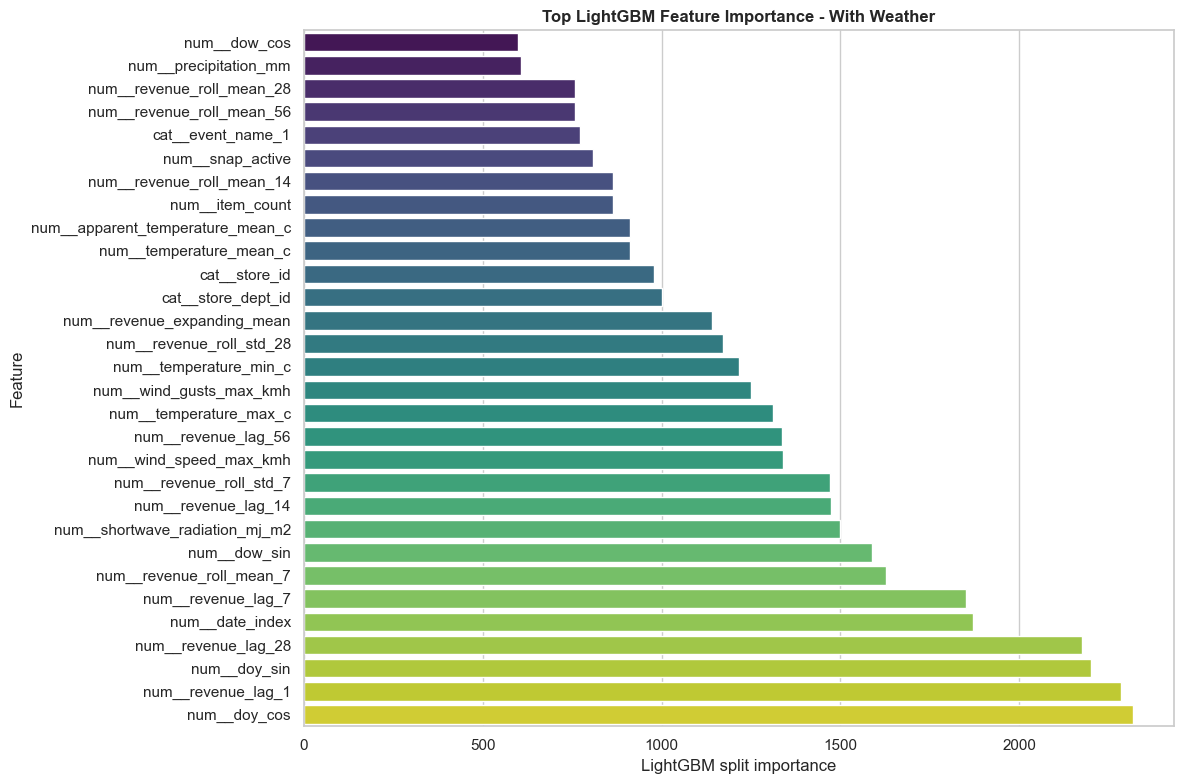

In [67]:
def get_transformed_feature_names(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        names = []
        for name, transformer, cols in preprocessor.transformers_:
            if name == "remainder" or transformer == "drop":
                continue
            if hasattr(transformer, "get_feature_names_out"):
                try:
                    names.extend(transformer.get_feature_names_out(cols))
                except Exception:
                    names.extend(cols)
            else:
                names.extend(cols)
        return np.array(names)


def lightgbm_importance_table(model, top_n=30):
    estimator = model.named_steps["model"]
    feature_names = get_transformed_feature_names(model)
    values = estimator.feature_importances_

    n = min(len(feature_names), len(values))
    out = pd.DataFrame({
        "feature": feature_names[:n],
        "importance": values[:n],
    })
    return out.sort_values("importance", ascending=False).head(top_n)

importance_df = lightgbm_importance_table(primary_model, top_n=30)
display(importance_df)

plt.figure(figsize=(12, 8))
plot_df = importance_df.sort_values("importance")
sns.barplot(data=plot_df, x="importance", y="feature", palette="viridis")
plt.title("Top LightGBM Feature Importance - With Weather")
plt.xlabel("LightGBM split importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# 20. Kết Luận Tổng Hợp
Kết luận chính:

1. Bài toán dự báo là `store_id × dept_id × date`, target là `daily_revenue`.
2. Model duy nhất: `LGBMRegressor` với objective `regression_l1`.
3. Feature set duy nhất: `with_weather`.
4. `store_dept_id` được thêm vào như interaction hợp lệ giữa store và department.
5. Model được validation trên năm 2015, sau đó train lại trên 2011-2015 và test cuối trên 2016.
6. Driver quan trọng nhất vẫn là lịch sử doanh thu, seasonality, baseline `store × dept`, SNAP/event, trend và weather conditions.